## Librerias:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from scipy.special import expit
from scipy.stats import multivariate_normal
import plotly.figure_factory as ff
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import plotly.graph_objects as go
from ipywidgets import widgets, interact

## 📚DataFrame y copy

In [ ]:
df = pd.read_csv('/content/loans_full_schema_probabilidad_default.csv')

In [ ]:
df_copy = df.copy()

In [ ]:
df

,Column1,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,default,prob_default
0,1,global config engineer,3.0,NJ,MORTGAGE,90000,Verified,18.01,NaN,NaN,...,Current,whole,Cash,2701586,199933,98414,101519,0,0,0.126345
1,2,warehouse office clerk,10.0,HI,RENT,40000,Not Verified,5.04,NaN,NaN,...,Current,whole,Cash,465137,49912,34863,15049,0,1,0.220467
2,3,assembly,3.0,WI,RENT,40000,Source Verified,21.15,NaN,NaN,...,Current,fractional,Cash,182463,2818,17537,10643,0,0,0.137414
3,4,customer service,1.0,PA,RENT,30000,Not Verified,10.16,NaN,NaN,...,Current,whole,Cash,1885326,331289,274674,56615,0,1,0.215280
4,5,security supervisor,10.0,CA,RENT,35000,Verified,57.96,57000.0,Verified,...,Current,whole,Cash,2143015,232465,156985,7548,0,0,0.137136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,owner,10.0,TX,RENT,108000,Source Verified,22.28,NaN,NaN,...,Current,whole,Cash,2158634,29698,241366,55614,0,1,0.165629
9996,9997,director,8.0,PA,MORTGAGE,121000,Verified,32.38,NaN,NaN,...,Current,whole,Cash,914744,145631,85256,60375,0,0,0.109044
9997,9998,toolmaker,10.0,CT,MORTGAGE,67000,Verified,45.26,107000.0,Source Verified,...,Current,fractional,Cash,2761765,46208,238235,223845,0,0,0.135202
9998,9999,manager,1.0,WI,MORTGAGE,80000,Source Verified,11.99,NaN,NaN,...,Current,whole,Cash,2151812,287331,248188,39143,0,0,0.108263


## 📦Exploracion inicial de los datos

In [ ]:
df.drop(columns=['Column1'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  int64  
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [ ]:
df.describe()

,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,...,loan_amount,term,interest_rate,installment,balance,paid_principal,paid_interest,paid_late_fees,default,prob_default
count,9183.000000,1.000000e+04,9976.000000,1.495000e+03,1495.000000,10000.00000,4342.000000,10000.00000,10000.00000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.00000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,5.930306,1.089188e+05,19.308192,1.279146e+05,19.979304,0.21600,36.760709,2001.29000,1.95820,22.679600,...,16361.922500,43.272000,1173.246300,43049.44400,1.309883e+06,1.087534e+05,55007.903100,2.110007e+06,0.141500,0.141476
std,3.703734,4.341665e+05,15.004851,7.016838e+04,8.054781,0.68366,21.634939,7.79551,2.38013,11.885439,...,10301.956759,11.029877,536.423572,30616.68524,1.029654e+06,1.187788e+05,51787.656645,2.110000e+08,0.348554,0.051858
min,0.000000,0.000000e+00,0.000000,1.920000e+04,0.320000,0.00000,1.000000,1963.00000,0.00000,2.000000,...,1000.000000,36.000000,6.000000,123.00000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.001119
25%,2.000000,4.500000e+04,11.057500,8.683350e+04,14.160000,0.00000,19.000000,1997.00000,0.00000,14.000000,...,8000.000000,36.000000,796.000000,19797.25000,4.634990e+05,4.000000e+04,16952.750000,0.000000e+00,0.000000,0.111992
50%,6.000000,6.500000e+04,17.570000,1.130000e+05,19.720000,0.00000,34.000000,2003.00000,1.00000,21.000000,...,14500.000000,36.000000,1091.000000,35941.00000,1.069486e+06,7.956650e+04,39002.500000,0.000000e+00,0.000000,0.137814
75%,10.000000,9.600000e+04,25.002500,1.515455e+05,25.500000,0.00000,53.000000,2006.00000,3.00000,29.000000,...,24000.000000,60.000000,1504.000000,60917.00000,1.921708e+06,1.401260e+05,77123.000000,0.000000e+00,0.000000,0.167324
max,10.000000,1.132132e+07,469.090000,1.100000e+06,39.980000,13.00000,118.000000,2015.00000,29.00000,87.000000,...,40000.000000,60.000000,3094.000000,156659.00000,3.930829e+06,2.678971e+06,421644.000000,2.110000e+10,1.000000,1.000000


## 📘 Diccionario de Datos — Loan Tape

###🏦 Información del Préstamo

| **Variable**          | **Descripción**                               |
| --------------------- | --------------------------------------------- |
| `application_type`    | Tipo de aplicación                            |
| `loan_amount`         | Monto total del préstamo solicitado           |
| `term`                | Plazo del préstamo en meses                   |
| `interest_rate`       | Tasa de interés anual aplicada al préstamo    |
| `installment`         | Cuota mensual del préstamo                    |
| `grade`               | Calificación general del préstamo             |
| `sub_grade`           | Subcategoría de la calificación               |
| `issue_month`         | Mes en que se emitió el préstamo              |
| `loan_status`         | Estado actual del préstamo                    |
| `initial_list_status` | Estado inicial de la publicación del préstamo |
| `disbursement_method` | Método de desembolso del préstamo             |
| `balance`             | Saldo restante del préstamo                   |
| `paid_total`          | Total pagado hasta la fecha                   |
| `paid_principal`      | Principal pagado                              |
| `paid_interest`       | Intereses pagados                             |
| `paid_late_fees`      | Monto pagado en cargos por mora               |


### 💳 Historial Crediticio y Comportamiento Financiero

| **Variable**                    | **Descripción**                                            |
| ------------------------------- | ---------------------------------------------------------- |
| `num_historical_failed_to_pay`  | Número histórico de incumplimientos de pago                |
| `months_since_90d_dp`           | Meses desde el último impago de más de 90 días             |
| `months_since_last_credit_inqu` | Meses desde la última consulta de crédito                  |
| `current_accounts_delinq`       | Número de cuentas actualmente en morosidad                 |
| `total_collection_amount_ever`  | Monto total acumulado en cuentas en cobranza               |
| `current_installment_accounts`  | Número de cuentas de cuotas activas                        |
| `accounts_opened_24m`           | Número de cuentas abiertas en los últimos 24 meses         |
| `num_satisfactory_accounts`     | Número de cuentas con historial satisfactorio              |
| `num_accounts_120d_past_due`    | Número de cuentas con impago superior a 120 días           |
| `num_accounts_30d_past_due`     | Número de cuentas con impago superior a 30 días            |
| `num_active_credit_accounts`    | Número de cuentas de crédito activas                       |
| `total_debt`                    | Deuda total acumulada                                      |
| `num_total_cc_accounts`         | Número total de cuentas de tarjeta de crédito              |
| `num_open_cc_accounts`          | Número de cuentas de tarjeta de crédito abiertas           |
| `num_cc_carrying_balance`       | Número de tarjetas con saldo pendiente                     |
| `num_mort_accounts`             | Número de cuentas hipotecarias                             |
| `account_never_delinq_percent`  | Porcentaje de cuentas sin historial de morosidad           |
| `tax_liens`                     | Número de gravámenes fiscales registrados                  |
| `public_record_bankrupt`        | Número de registros públicos de bancarrota                 |
| `months_since_last_delin`       | Meses desde la última morosidad                            |
| `earliest_cr_line`              | Fecha de apertura de la primera línea de crédito           |
| `inquiries_last_12m`            | Número de consultas de crédito en los últimos 12 meses     |
| `open_acc_6m`                   | Número de cuentas abiertas en los últimos 6 meses          |
| `open_act_il`                   | Número de cuentas de crédito a plazos abiertas actualmente |
| `total_credit_limit`            | Límite total de crédito disponible                         |
| `total_credit_utilized`         | Total de crédito utilizado                                 |
| `num_collections_last_12m`      | Número de cuentas en cobranza en los últimos 12 meses      |


### 👩‍💼 Información Laboral y de Ingresos

| **Variable**               | **Descripción**                             |
| -------------------------- | ------------------------------------------- |
| `emp_title`                | Título del empleo del solicitante           |
| `emp_length`               | Tiempo de empleo en años                    |
| `state`                    | Estado de residencia del solicitante        |
| `homeownership`            | Tipo de tenencia de vivienda                |
| `annual_income`            | Ingreso anual individual del solicitante    |
| `verified_income`          | Estado de verificación del ingreso          |
| `debt_to_income`           | Relación deuda-ingreso individual           |
| `annual_income_joint`      | Ingreso anual conjunto (si aplica)          |
| `verification_income_join` | Estado de verificación del ingreso conjunto |
| `debt_to_income_joint`     | Relación deuda-ingreso conjunta             |


### 🎯 Variable Objetivo

| **Variable**             | **Descripción**                                                                                                |
| :----------------------- | :------------------------------------------------------------------------------------------------------------- |
| **probabilidad_default** | Probabilidad estimada de incumplimiento |


## 🧹 Preparacion y limpieza de Datos

In [ ]:
nulos = df.isnull().sum()

# Calcular porcentaje de nulos por columna
porcentaje_nulos = (nulos / len(df)) * 100

# Unir los resultados en un solo DataFrame ordenado
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

# Mostrar tabla ordenada (de mayor a menor cantidad de nulos)
print("Cantidad y porcentaje de valores nulos por columna:\n")
display(resumen_nulos)

Cantidad y porcentaje de valores nulos por columna:



,Nulos,Porcentaje (%)
verification_income_joint,8545,85.45
annual_income_joint,8505,85.05
debt_to_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24


In [ ]:
df['verification_income_joint'] = df['verification_income_joint'].fillna('Not applicable')

In [ ]:
df['annual_income_joint'] = df['annual_income_joint'].fillna(0) ##no aplica

In [ ]:
df['debt_to_income_joint'] = df['debt_to_income_joint'].fillna(0) ## no aplica

In [ ]:
df['disbursement_method'].unique()

array(['Cash', 'DirectPay'], dtype=object)

In [ ]:
df['issue_month'].unique()

array(['Mar-2018', 'Feb-2018', 'Jan-2018'], dtype=object)

In [ ]:
df['paid_total'] = (
    df['paid_total']
    .astype(str)                      # asegura que todo sea texto
    .str.replace(',', '', regex=False) # quita comas
)

In [ ]:
df['paid_total'] = pd.to_numeric(df['paid_total'], errors='coerce')

In [ ]:
obj_cols = df.select_dtypes(include='object').columns
print("Columnas tipo object:", list(obj_cols))

# Codificar las columnas de tipo object en la misma columna
for col in obj_cols:
    df[col] = df[col].astype('category').cat.codes

# Mostrar resultado
print("Codificación completada.")
df[obj_cols].head()

Columnas tipo object: ['emp_title', 'state', 'homeownership', 'verified_income', 'verification_income_joint', 'loan_purpose', 'application_type', 'grade', 'sub_grade', 'issue_month', 'loan_status', 'initial_listing_status', 'disbursement_method']
Codificación completada.


,emp_title,state,homeownership,verified_income,verification_income_joint,loan_purpose,application_type,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method
0,1777,30,0,2,1,7,0,2,12,2,1,1,0
1,4675,11,2,0,1,2,0,2,10,0,1,1,0
2,207,47,2,1,1,8,0,3,15,0,1,0,0
3,1035,37,2,0,1,2,0,0,2,1,1,1,0
4,3710,4,2,2,3,1,1,2,12,2,1,1,0


#📊EDA

In [ ]:
df['grade'].unique()

array([2, 3, 0, 1, 5, 4, 6], dtype=int8)

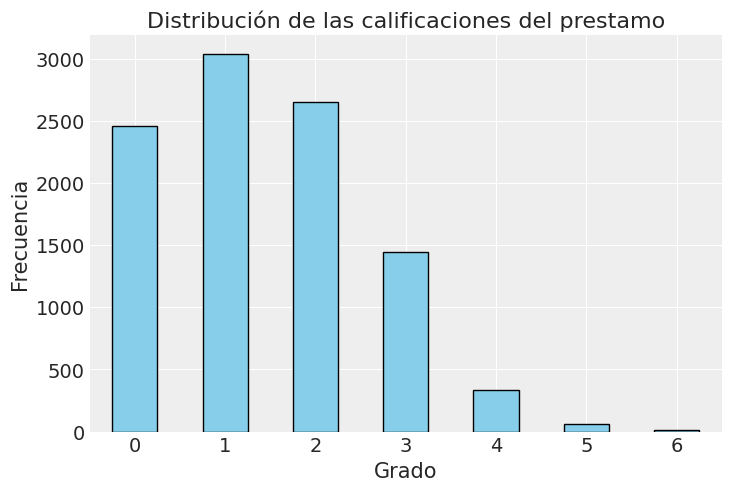

In [ ]:
conteo = df['grade'].value_counts().sort_index()

# Graficar
conteo.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribución de las calificaciones del prestamo')
plt.xlabel('Grado')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df['paid_late_fees'].value_counts()

,count
paid_late_fees,
0,9948
15,19
30,3
2331,3
4512,2
1676,2
3282,1
3075,1
2564,1


/tmp/ipython-input-2372285187.py:21: UserWarning:

The figure layout has changed to tight



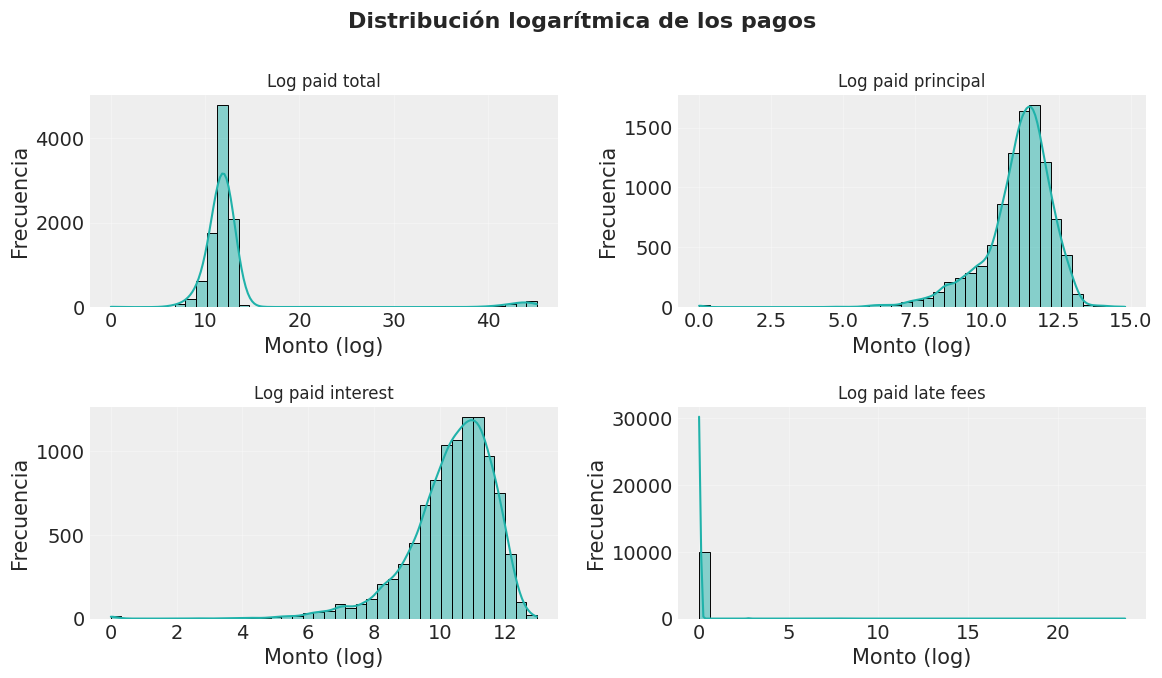

In [ ]:
pagos = ['paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees']

# --- 2. Crear columnas logarítmicas ---
for col in pagos:
    df[f'log_{col}'] = np.log1p(df[col])  # log(1 + x) evita problemas con ceros o valores negativos

# --- 3. Preparar lista de columnas logarítmicas ---
log_pagos = [f'log_{c}' for c in pagos]

# --- 4. Graficar ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Distribución logarítmica de los pagos', fontsize=16, weight='bold')

for ax, col in zip(axes.flatten(), log_pagos):
    sns.histplot(df[col], bins=40, kde=True, color='lightseagreen', ax=ax)
    ax.set_title(col.replace('_', ' ').capitalize(), fontsize=12)
    ax.set_xlabel('Monto (log)')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.tight_layout(pad=2)
plt.show()

In [ ]:
df['emp_title'].value_counts()

,count
emp_title,
-1,833
2410,218
2829,204
4362,201
1355,123
...,...
1204,1
1605,1
4094,1


/tmp/ipython-input-1731316002.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




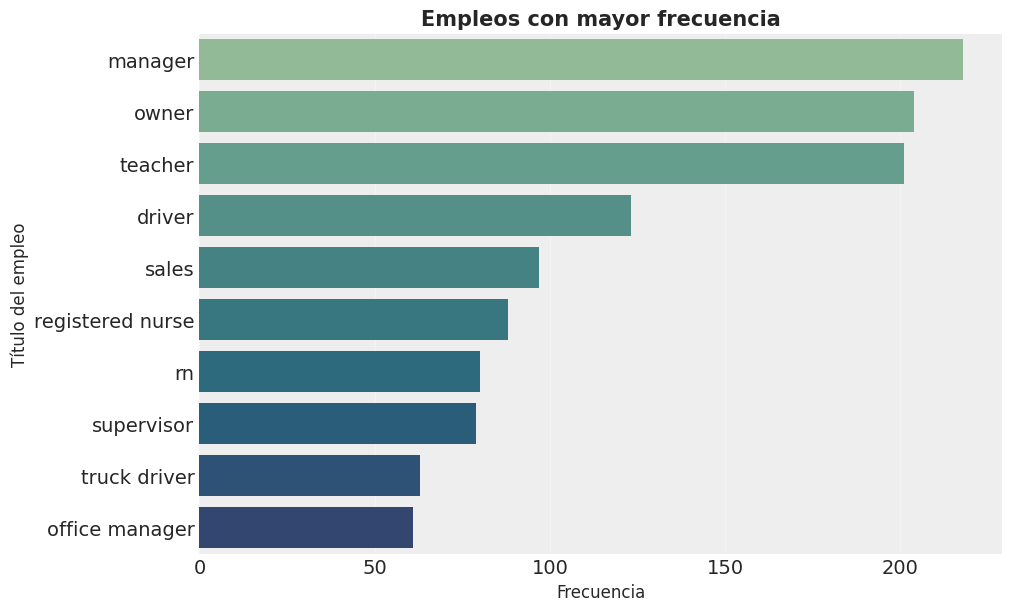

In [ ]:
top_emp = df_copy['emp_title'].value_counts().head(10)  # Top 10 empleos

# Crear el gráfico
plt.figure(figsize=(10,6))
sns.barplot(x=top_emp.values, y=top_emp.index, palette='crest')

# Personalizar
plt.title('Empleos con mayor frecuencia', fontsize=15, weight='bold')
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Título del empleo', fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.show()

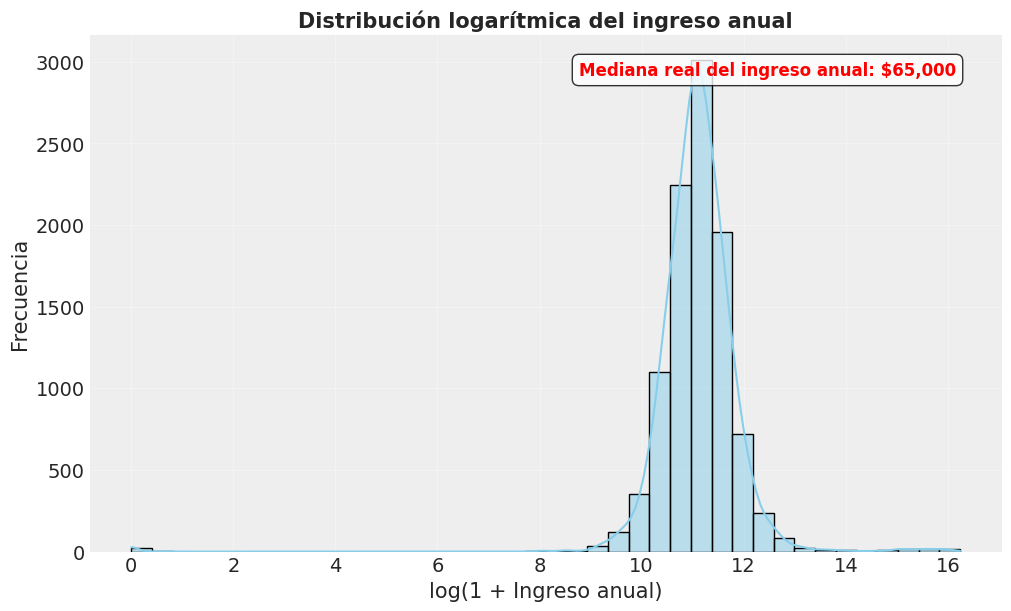

In [ ]:
median_income = df['annual_income'].median()

# Crear el gráfico con logaritmo en los datos
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['annual_income']), bins=40, kde=True, color='skyblue', edgecolor='black')

# Personalizar
plt.title('Distribución logarítmica del ingreso anual', fontsize=15, weight='bold')
plt.xlabel('log(1 + Ingreso anual)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Mostrar la mediana real como texto
plt.text(
    x=0.95, y=0.95,
    s=f"Mediana real del ingreso anual: ${median_income:,.0f}",
    ha='right', va='top', transform=plt.gca().transAxes,
    fontsize=12, color='red', weight='bold',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.show()

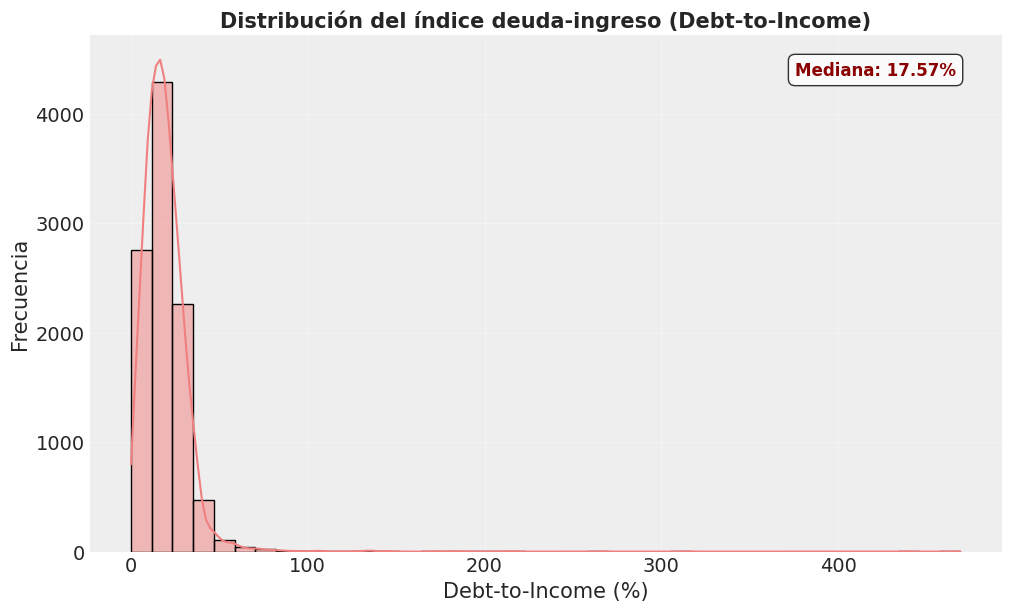

In [ ]:
median_dti = df['debt_to_income'].median()

# Crear el gráfico
plt.figure(figsize=(10,6))
sns.histplot(df['debt_to_income'], bins=40, kde=True, color='lightcoral', edgecolor='black')

# Personalizar
plt.title('Distribución del índice deuda-ingreso (Debt-to-Income)', fontsize=15, weight='bold')
plt.xlabel('Debt-to-Income (%)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)

# Mostrar la mediana como texto
plt.text(
    x=0.95, y=0.95,
    s=f"Mediana: {median_dti:.2f}%",
    ha='right', va='top', transform=plt.gca().transAxes,
    fontsize=12, color='darkred', weight='bold',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.show()


/tmp/ipython-input-3960344794.py:16: UserWarning:

The figure layout has changed to tight



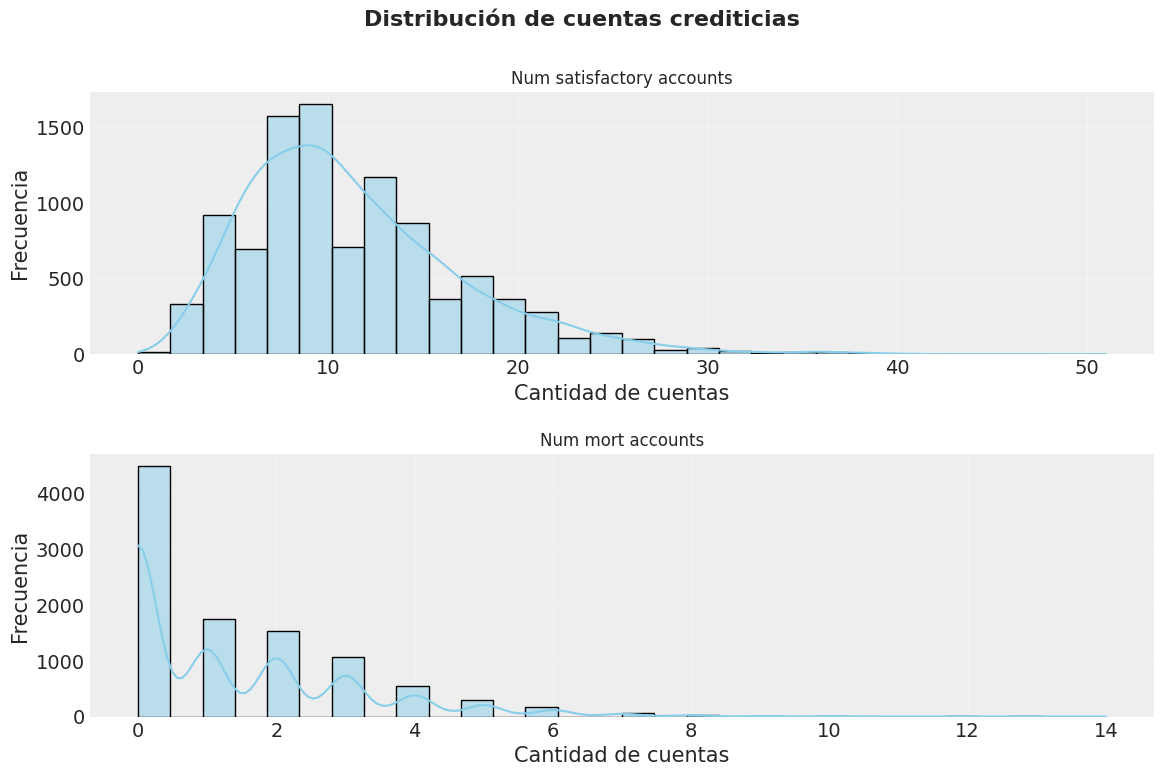

In [ ]:
cuentas = [
    'num_satisfactory_accounts',
    'num_mort_accounts'
]

fig, axes = plt.subplots(2, figsize=(12,8))
fig.suptitle('Distribución de cuentas crediticias', fontsize=16, weight='bold')

for ax, col in zip(axes.flatten(), cuentas):
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax)
    ax.set_title(col.replace('_', ' ').capitalize(), fontsize=12)
    ax.set_xlabel('Cantidad de cuentas')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)

plt.tight_layout(pad=2)
plt.show()

/tmp/ipython-input-692720941.py:16: UserWarning:

The figure layout has changed to tight



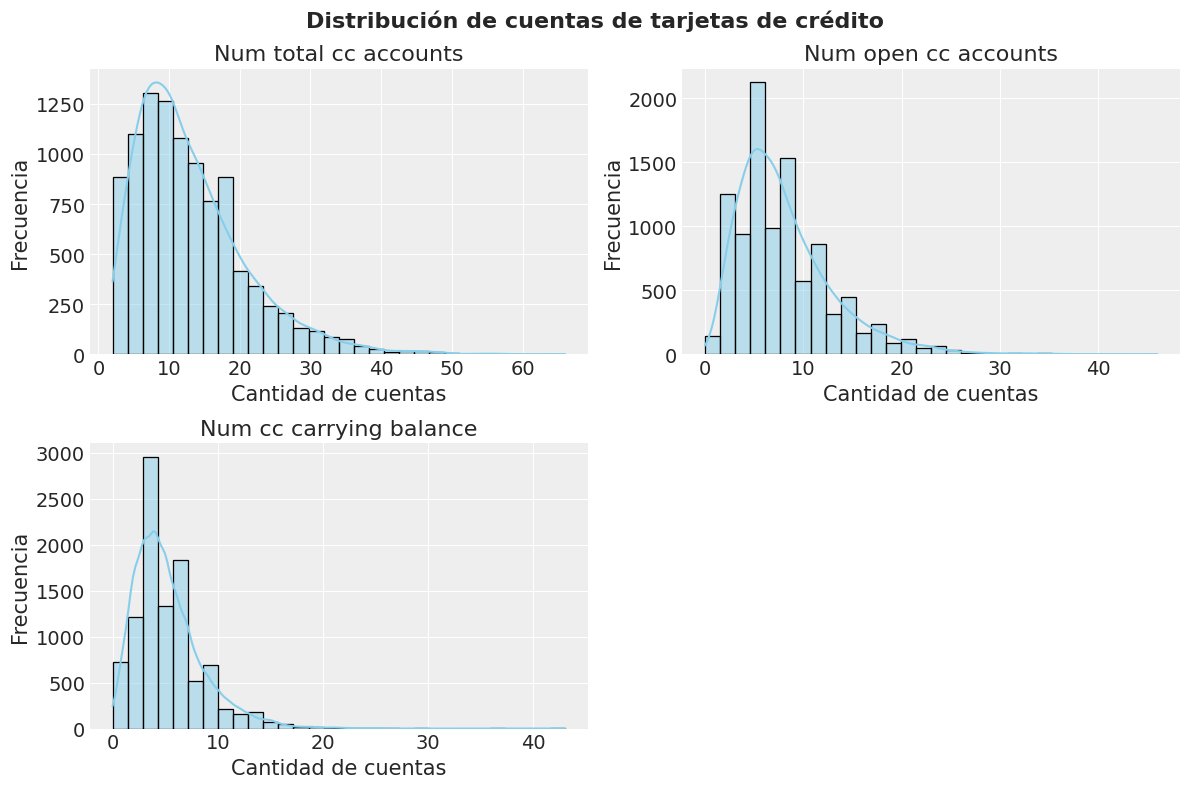

In [ ]:
cc_vars = [
    'num_total_cc_accounts',
    'num_open_cc_accounts',
    'num_cc_carrying_balance',
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(cc_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.title(col.replace('_', ' ').capitalize())
    plt.xlabel('Cantidad de cuentas')
    plt.ylabel('Frecuencia')

plt.suptitle('Distribución de cuentas de tarjetas de crédito', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2662486063.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




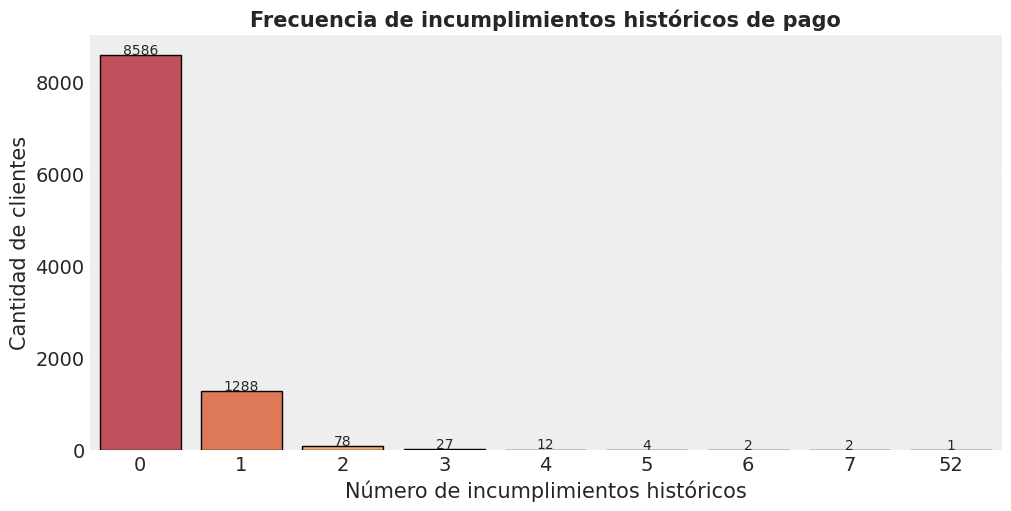

In [ ]:
counts = df['num_historical_failed_to_pay'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=counts.index, y=counts.values, palette='Spectral', edgecolor='black')

# Anotar las frecuencias
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10)

# Personalización
plt.title('Frecuencia de incumplimientos históricos de pago', fontsize=15, weight='bold')
plt.xlabel('Número de incumplimientos históricos')
plt.ylabel('Cantidad de clientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

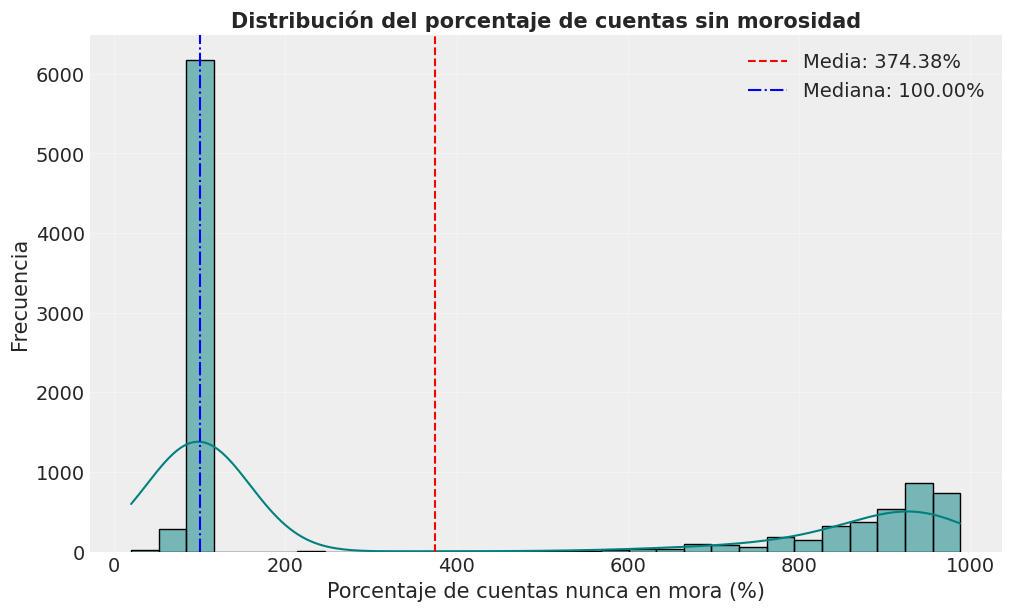

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['account_never_delinq_percent'], bins=30, kde=True, color='teal', edgecolor='black')

# Calcular estadísticas clave
mean_val = df['account_never_delinq_percent'].mean()
median_val = df['account_never_delinq_percent'].median()

# Añadir líneas de referencia
plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}%')
plt.axvline(median_val, color='blue', linestyle='-.', label=f'Mediana: {median_val:.2f}%')

plt.title('Distribución del porcentaje de cuentas sin morosidad', fontsize=15, weight='bold')
plt.xlabel('Porcentaje de cuentas nunca en mora (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

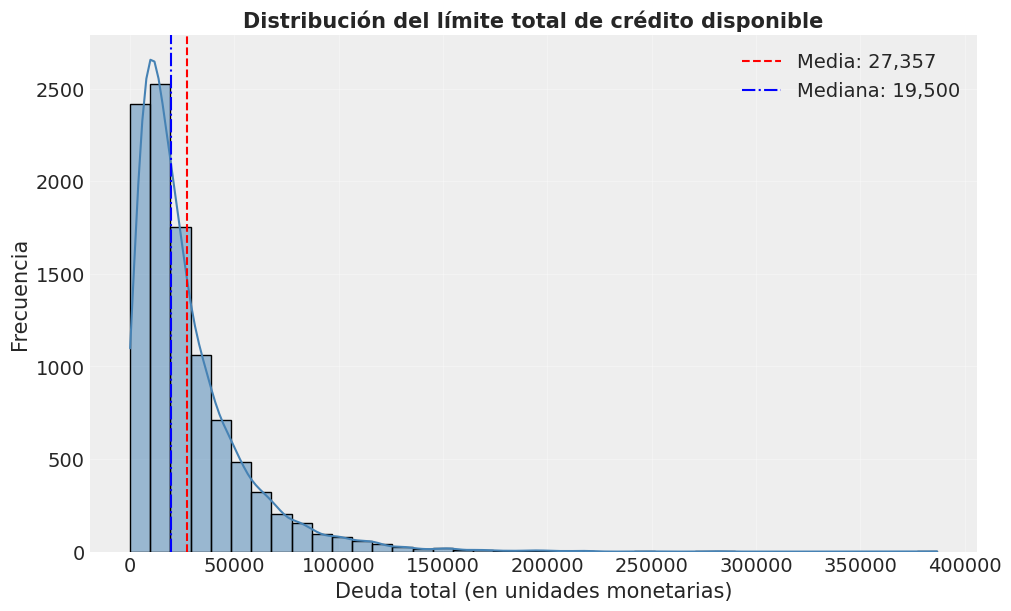

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['total_debit_limit'], bins=40, kde=True, color='steelblue', edgecolor='black')

# Estadísticos
mean_val = df['total_debit_limit'].mean()
median_val = df['total_debit_limit'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:,.0f}')
plt.axvline(median_val, color='blue', linestyle='-.', label=f'Mediana: {median_val:,.0f}')

plt.title('Distribución del límite total de crédito disponible', fontsize=15, weight='bold')
plt.xlabel('Deuda total (en unidades monetarias)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df.drop(['emp_title'], axis=1, inplace=True)

In [ ]:
df.corr()

,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,...,paid_total,paid_principal,paid_interest,paid_late_fees,default,prob_default,log_paid_total,log_paid_principal,log_paid_interest,log_paid_late_fees
emp_length,1.000000,0.012828,-0.216018,0.043558,0.016339,0.026157,0.040718,-0.002645,0.029542,0.008242,...,0.012909,0.033633,0.038969,0.003014,0.039203,-0.051446,0.006967,0.049210,0.033992,0.005309
state,0.012828,1.000000,-0.054833,-0.007402,0.001042,0.052622,-0.003215,-0.005235,0.013106,0.005772,...,-0.016390,-0.012667,-0.003666,-0.012562,-0.066529,-0.027405,-0.016867,-0.006516,-0.009079,-0.010847
homeownership,-0.216018,-0.054833,1.000000,-0.044285,-0.075553,-0.074289,-0.148495,-0.022720,-0.126303,-0.039036,...,-0.026625,-0.071080,-0.074438,0.011815,-0.006284,0.121059,-0.030483,-0.068203,-0.066103,0.018544
annual_income,0.043558,-0.007402,-0.044285,1.000000,0.015738,-0.037754,-0.009590,-0.018481,-0.028193,0.015030,...,0.017114,0.024392,0.034234,-0.001127,-0.003240,-0.006343,0.004976,0.025129,0.026492,0.000774
verified_income,0.016339,0.001042,-0.075553,0.015738,1.000000,0.101180,0.078814,0.321192,0.123314,0.011546,...,0.031550,0.077318,0.224467,-0.011505,0.012342,0.033713,0.029394,0.056197,0.166597,0.014513
debt_to_income,0.026157,0.052622,-0.074289,-0.037754,0.101180,1.000000,0.252726,0.186743,0.398046,-0.027517,...,-0.009089,-0.001047,0.114642,0.004679,0.001561,0.009950,-0.014556,0.024819,0.102077,-0.004335
annual_income_joint,0.040718,-0.003215,-0.148495,-0.009590,0.078814,0.252726,1.000000,0.211200,0.743498,0.006343,...,0.007673,0.072666,0.124962,-0.003604,-0.023518,-0.025351,0.009695,0.072816,0.093915,0.019591
verification_income_joint,-0.002645,-0.005235,-0.022720,-0.018481,0.321192,0.186743,0.211200,1.000000,0.328183,0.002111,...,0.001924,0.031295,0.105001,-0.001166,-0.001034,0.031716,-0.001416,0.029781,0.069687,0.027277
debt_to_income_joint,0.029542,0.013106,-0.126303,-0.028193,0.123314,0.398046,0.743498,0.328183,1.000000,-0.006396,...,0.005960,0.027864,0.140439,-0.003842,-0.022303,0.029260,-0.003520,0.044852,0.107166,0.010714
delinq_2y,0.008242,0.005772,-0.039036,0.015030,0.011546,-0.027517,0.006343,0.002111,-0.006396,1.000000,...,-0.005075,-0.028910,0.022233,-0.003160,-0.038041,-0.031623,-0.001647,-0.026874,0.021239,-0.009649


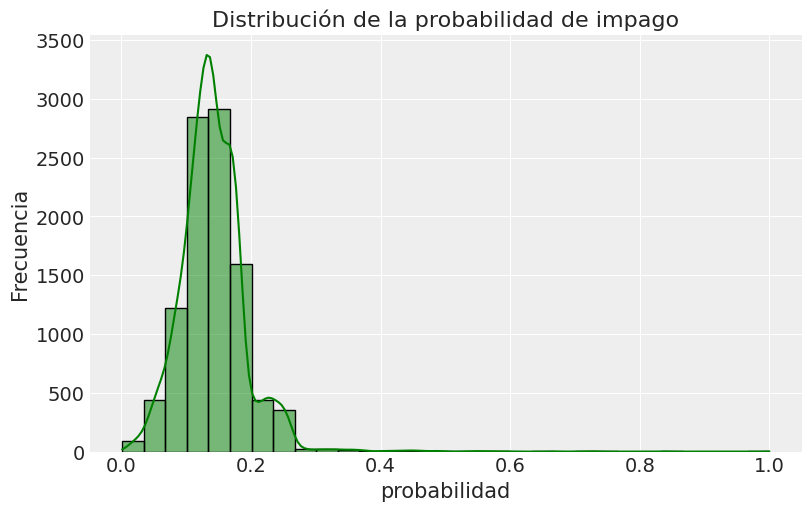

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['prob_default'], bins=30, kde=True, color='green')
plt.title('Distribución de la probabilidad de impago')
plt.xlabel('probabilidad')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
def plot_all_vs_prob_default(df, target='prob_default'):
    for col in df.columns:
        if col == target:
            continue  # no comparar consigo misma

        plt.figure(figsize=(7,4))

        # Si la variable es numérica
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.scatterplot(x=df[col], y=df[target], alpha=0.5)
            plt.title(f'{target} vs {col}')
            plt.xlabel(col)
            plt.ylabel(target)

        # Si la variable es categórica
        else:
            # limitar número de categorías para mejor visualización
            if df[col].nunique() <= 20:
                sns.boxplot(x=df[col], y=df[target], palette='Set3')
                plt.title(f'{target} según {col}')
                plt.xlabel(col)
                plt.ylabel(target)
                plt.xticks(rotation=45)
            else:
                print(f"Saltando {col} (demasiadas categorías: {df[col].nunique()})")
                plt.close()
                continue

        plt.tight_layout()
        plt.show()

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



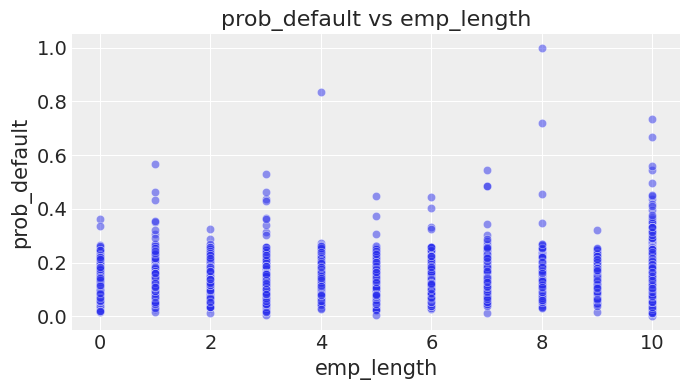

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



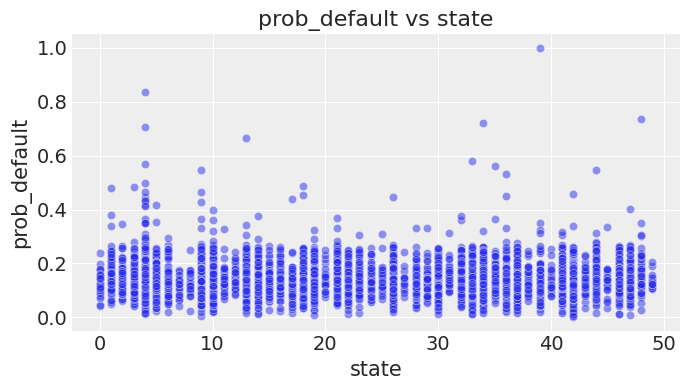

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



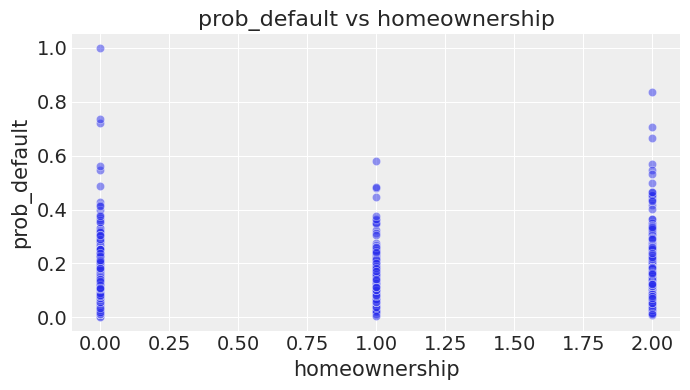

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



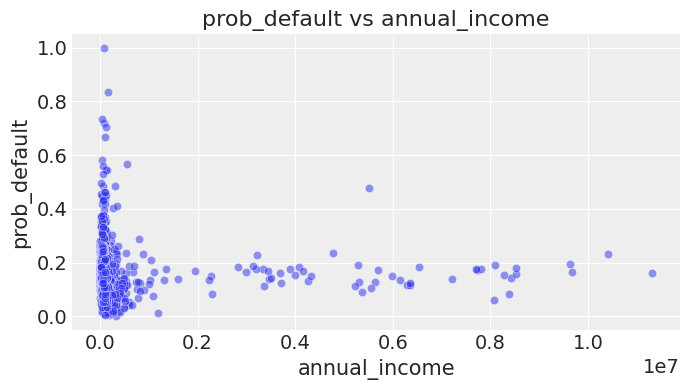

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



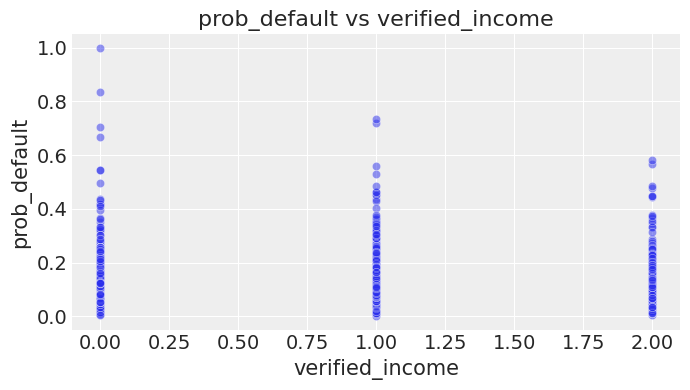

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



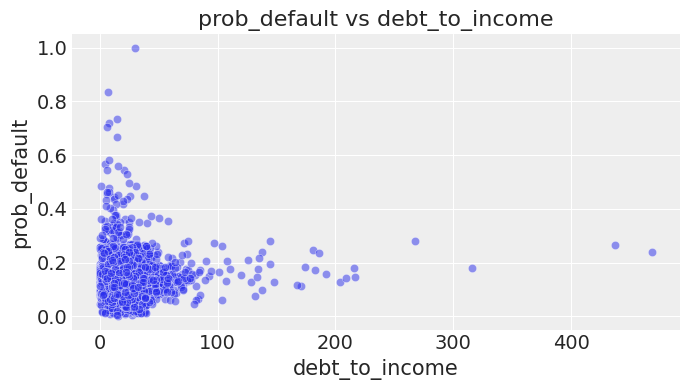

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



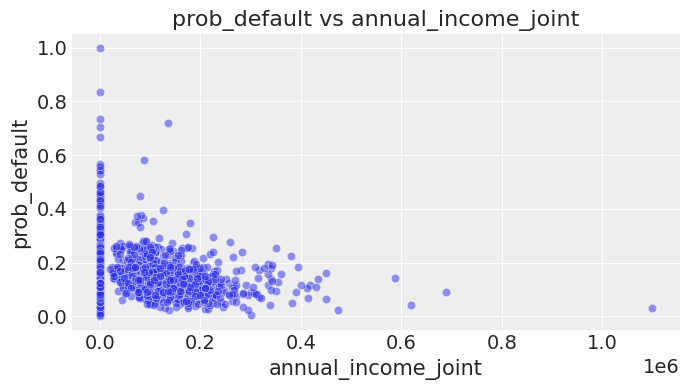

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



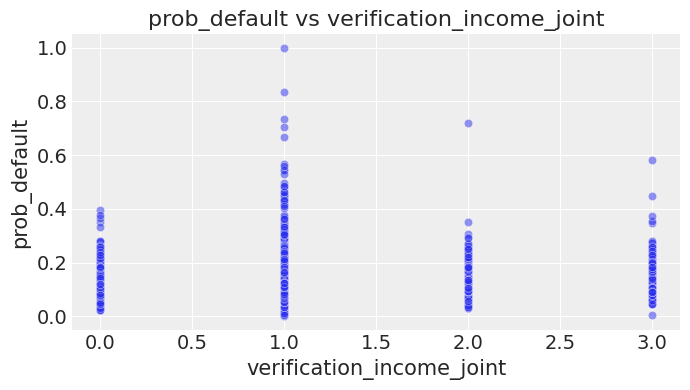

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



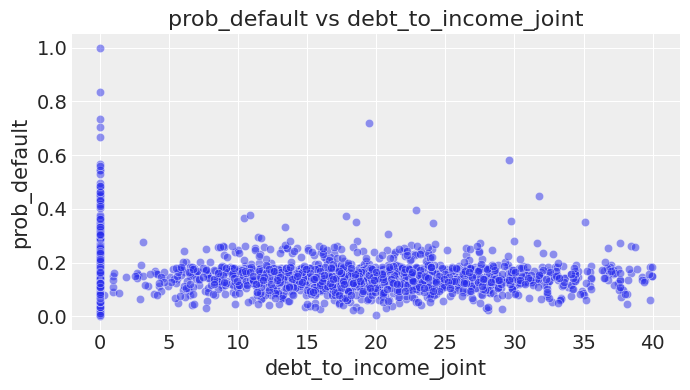

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



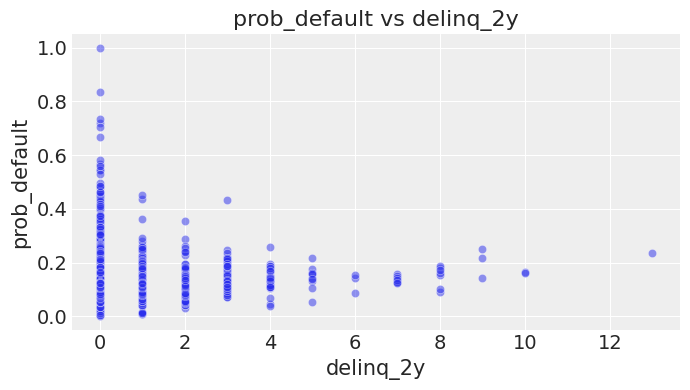

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



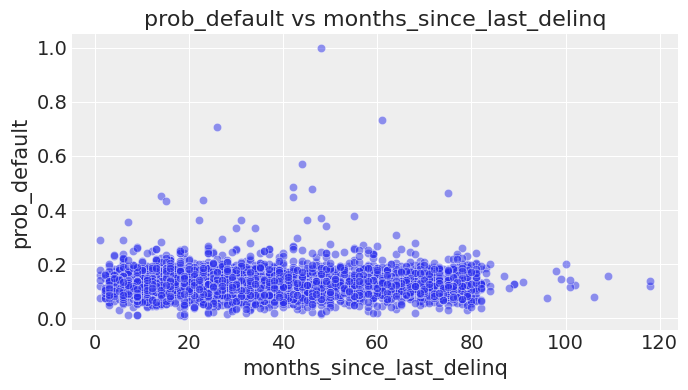

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



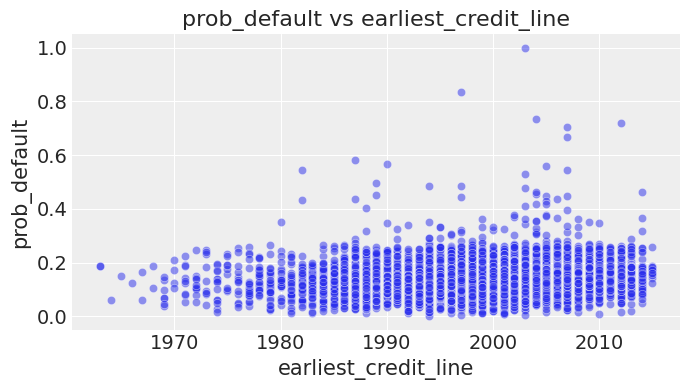

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



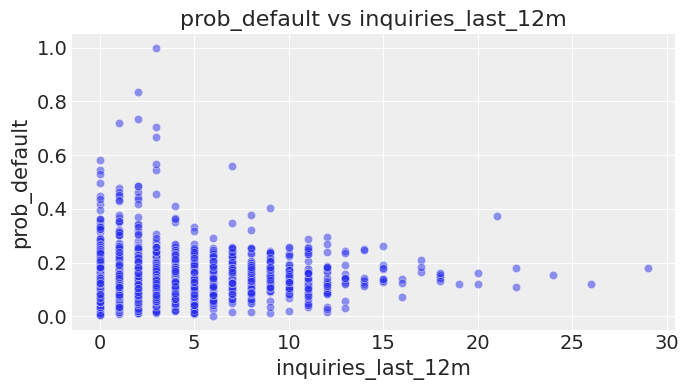

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



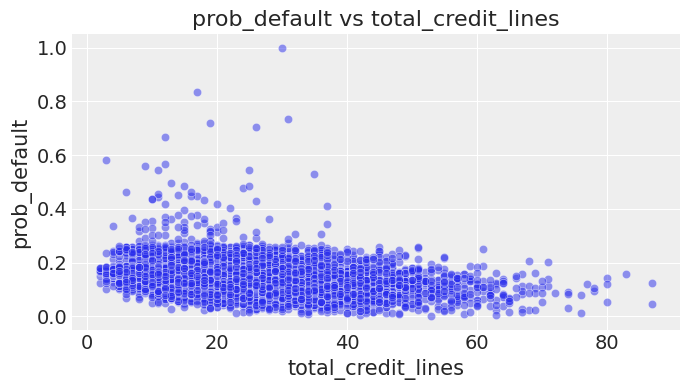

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



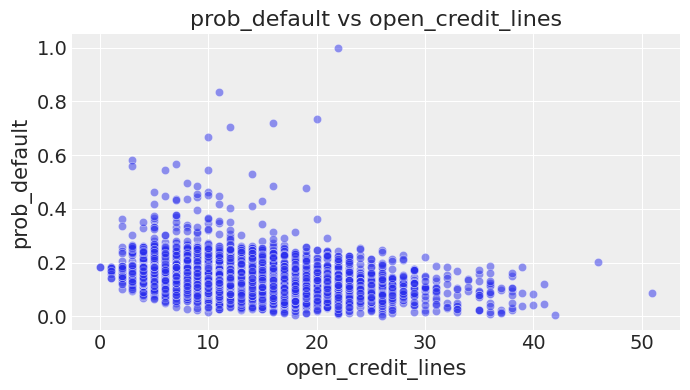

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



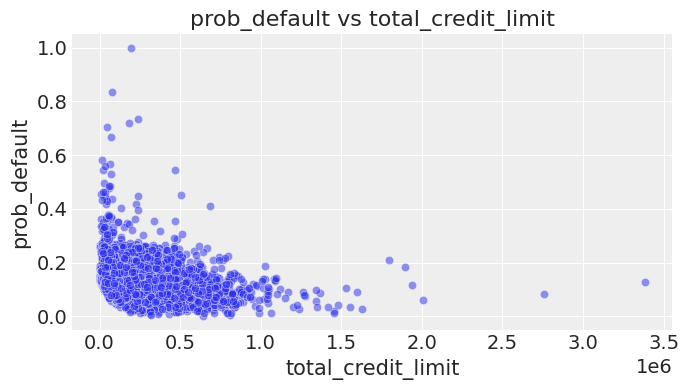

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



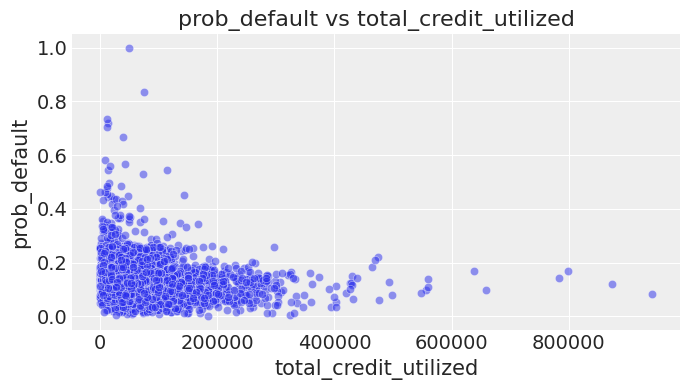

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



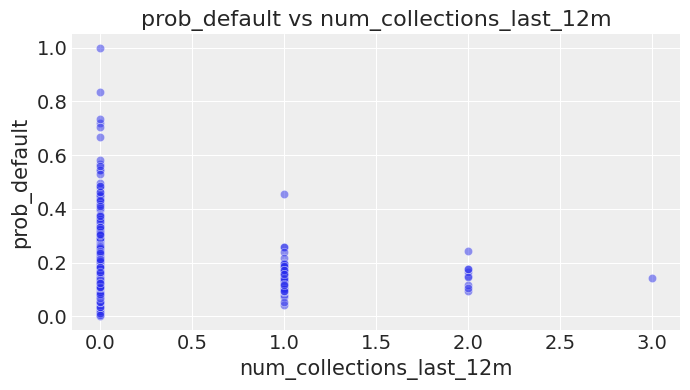

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



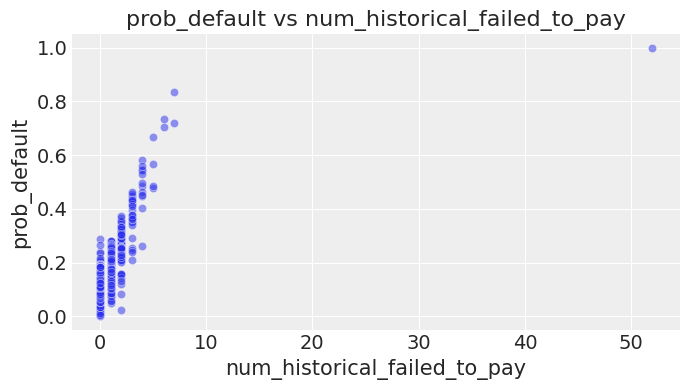

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



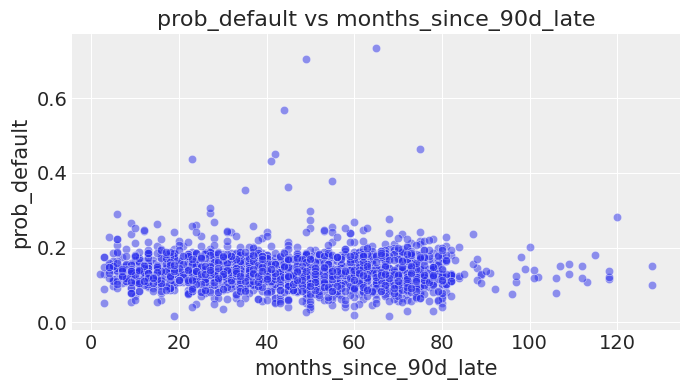

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



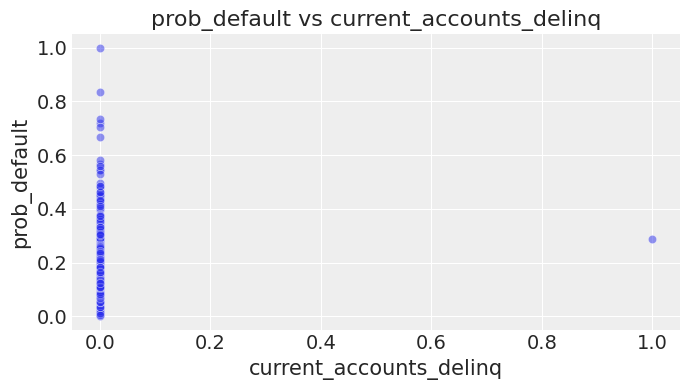

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



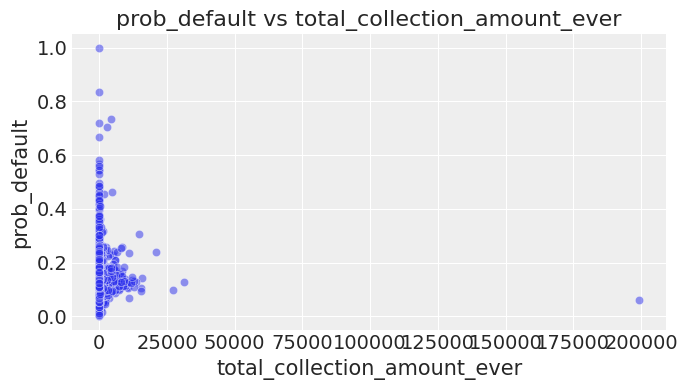

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



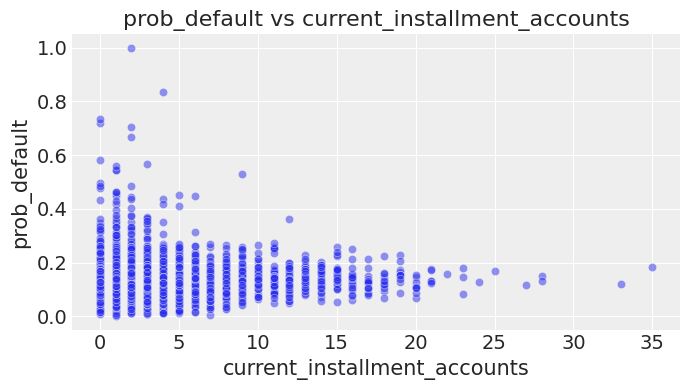

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



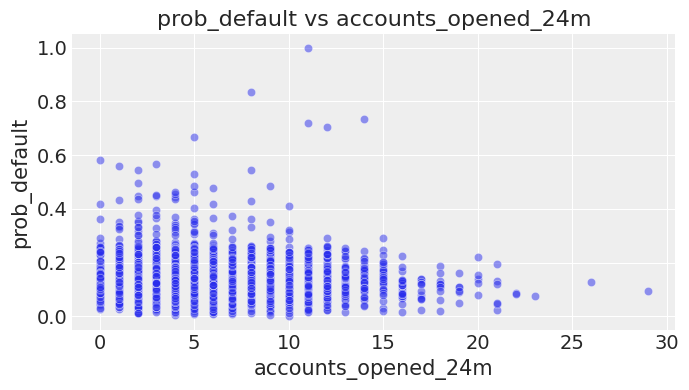

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



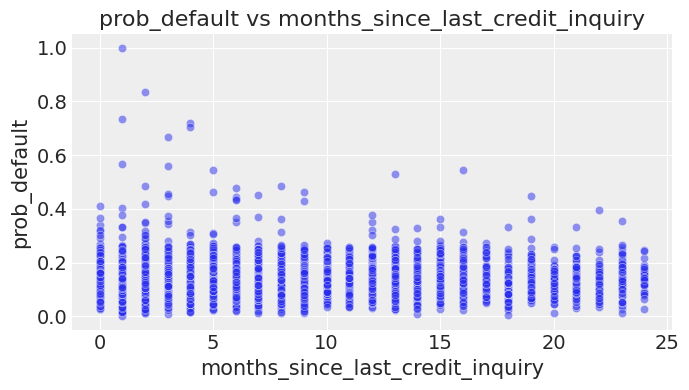

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



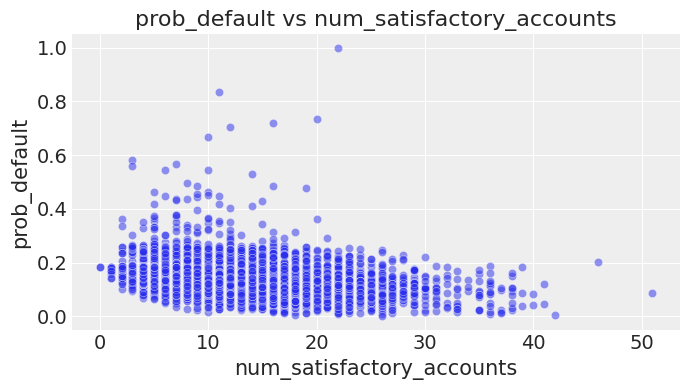

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



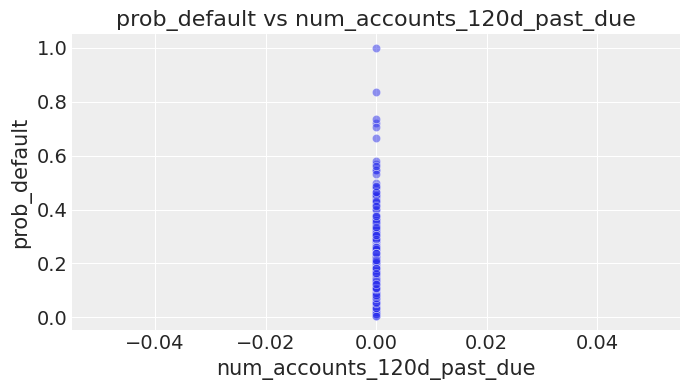

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



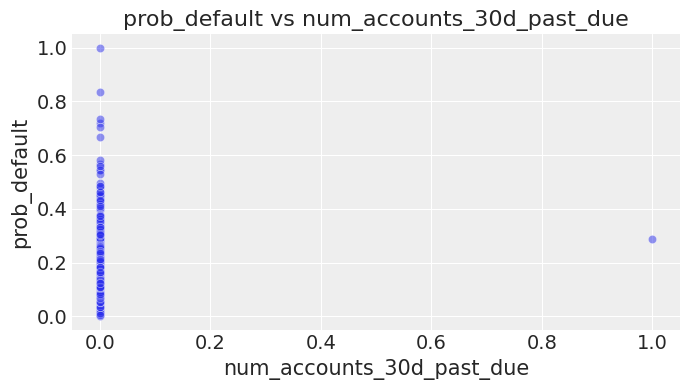

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



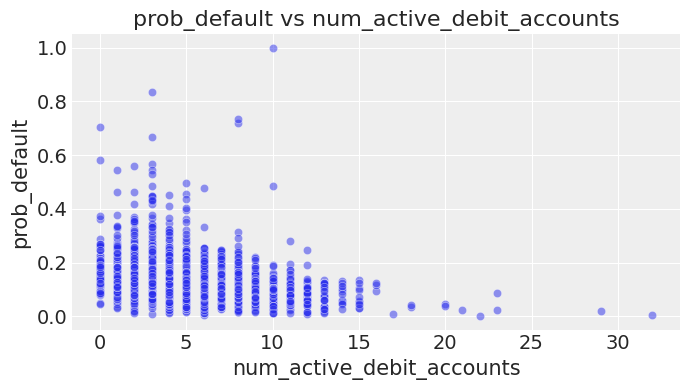

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



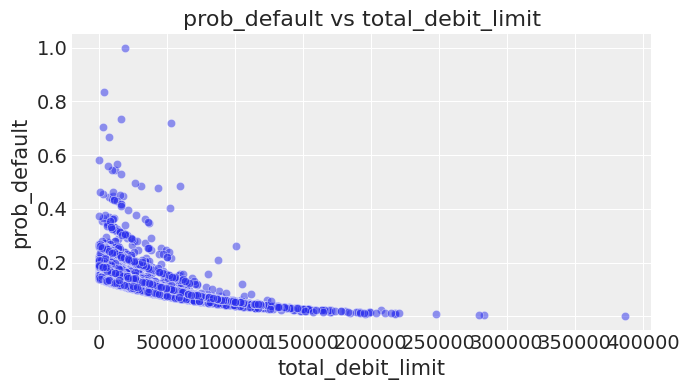

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



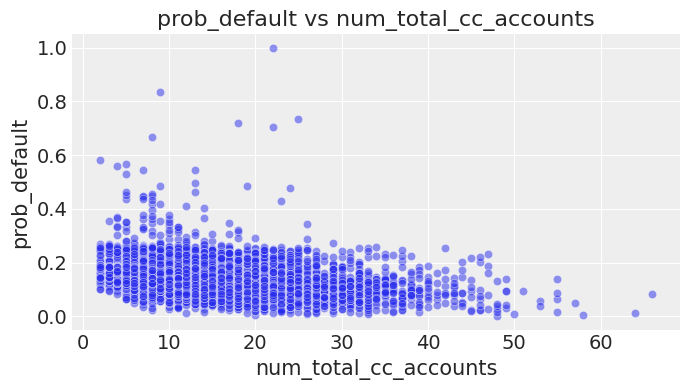

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



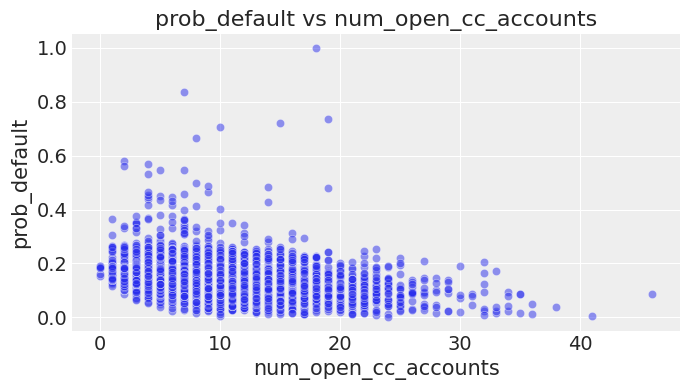

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



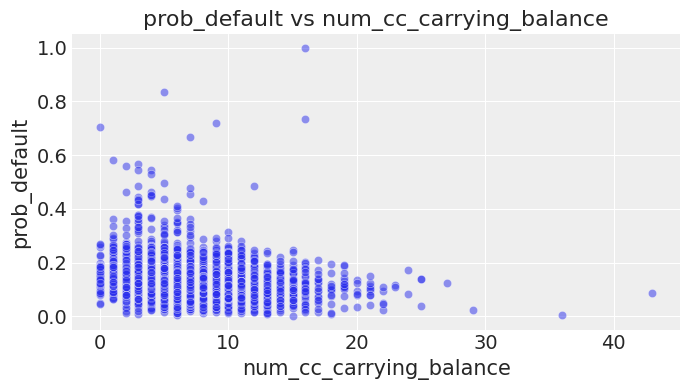

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



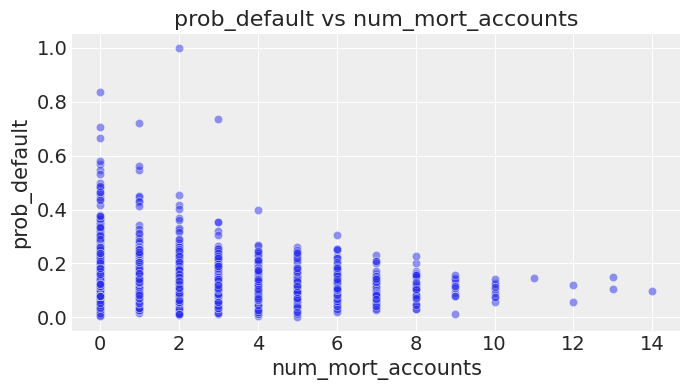

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



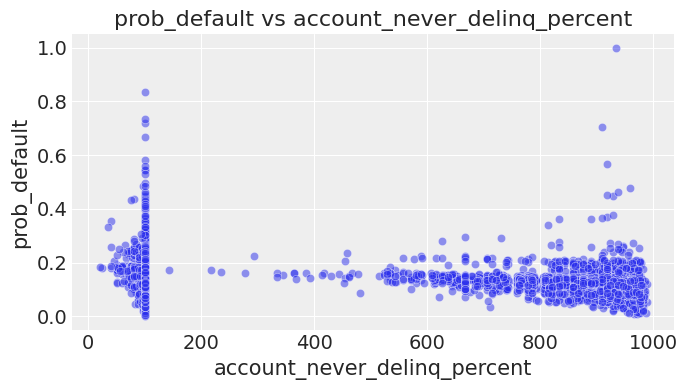

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



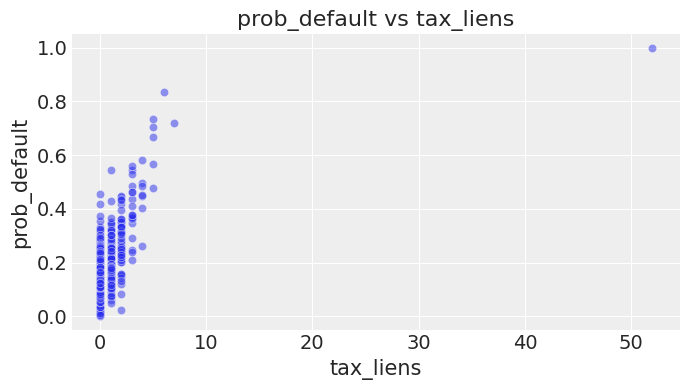

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



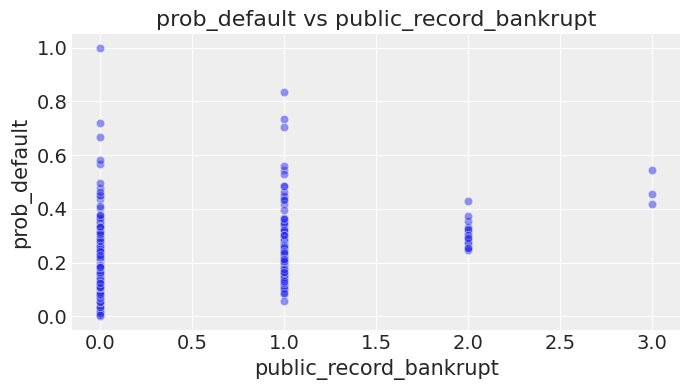

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



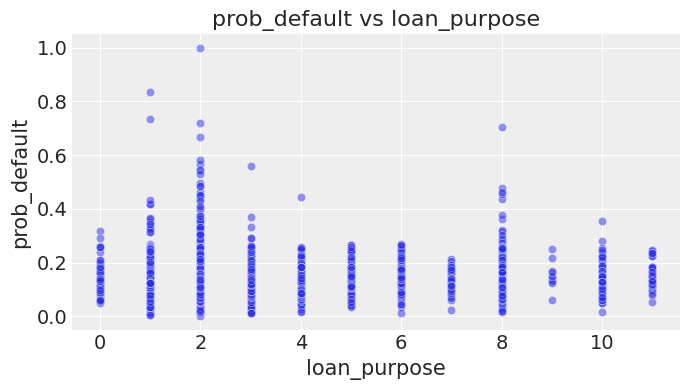

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



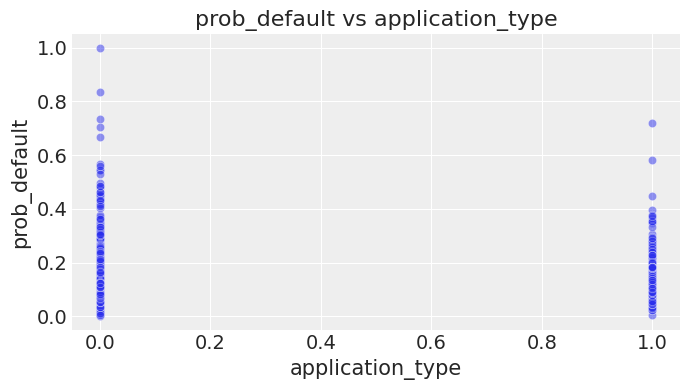

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



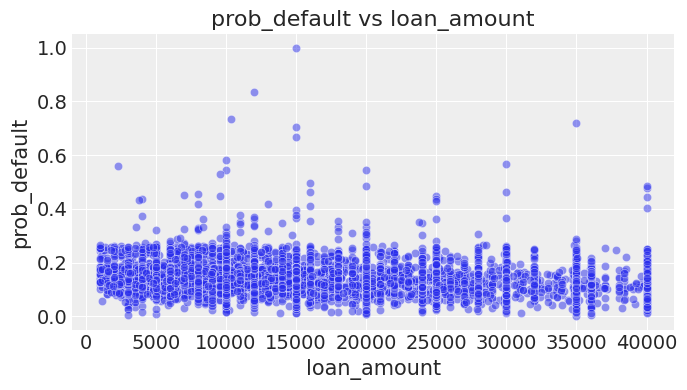

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



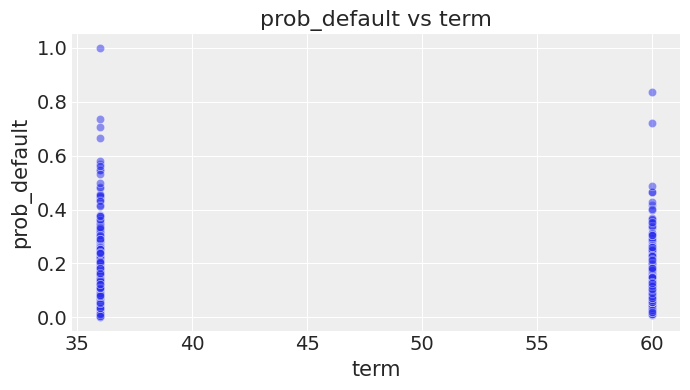

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



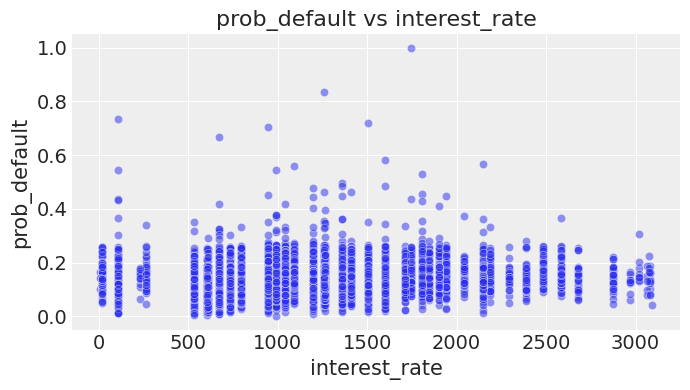

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



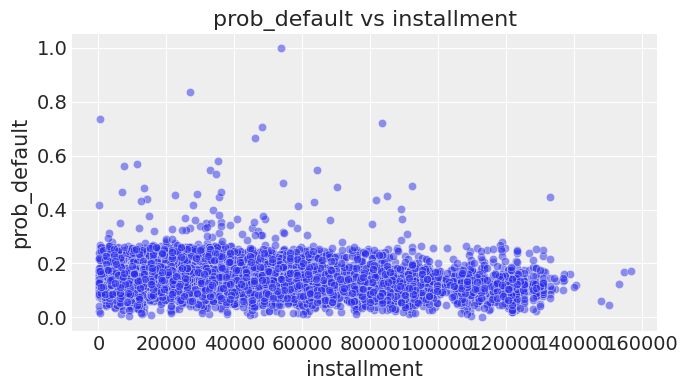

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



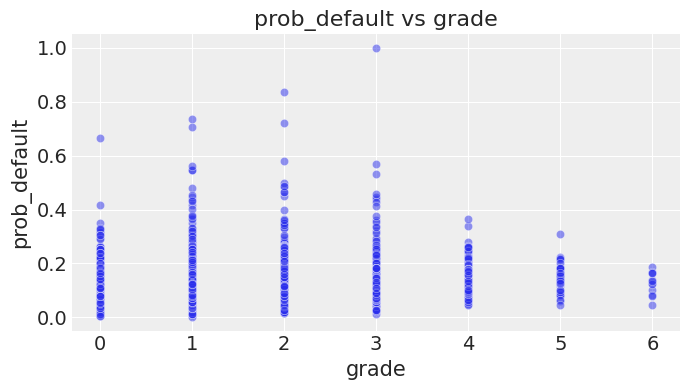

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



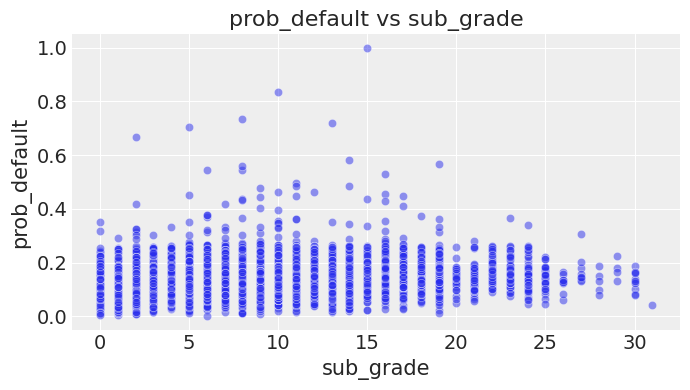

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



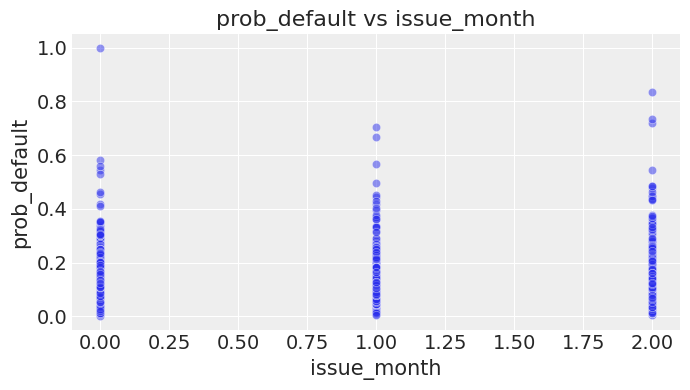

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



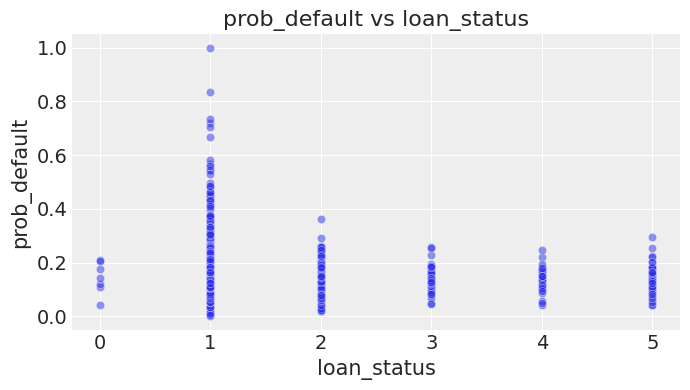

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



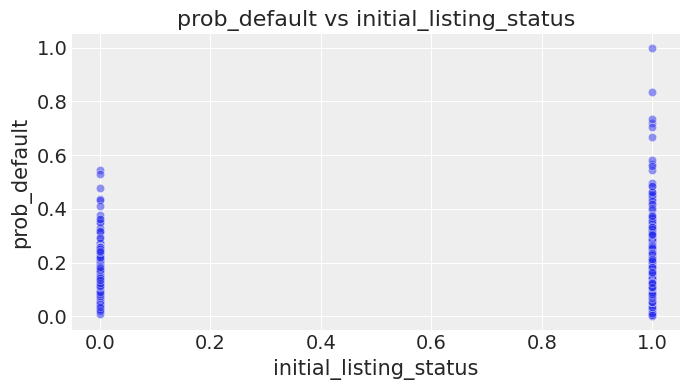

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



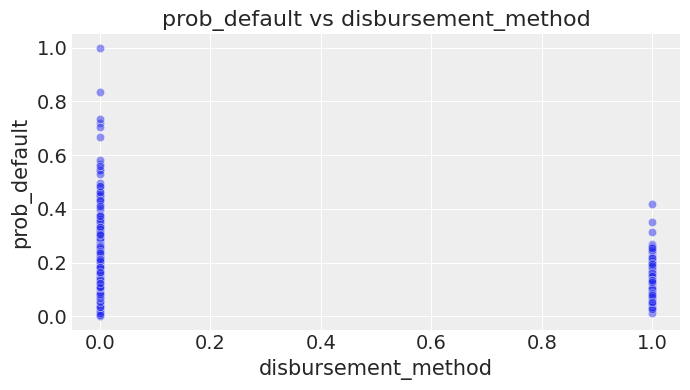

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



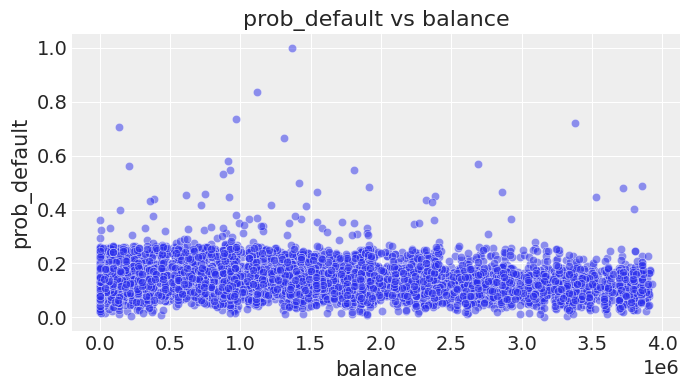

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



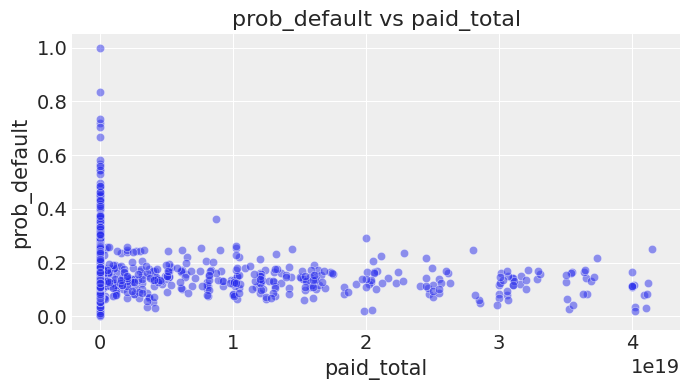

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



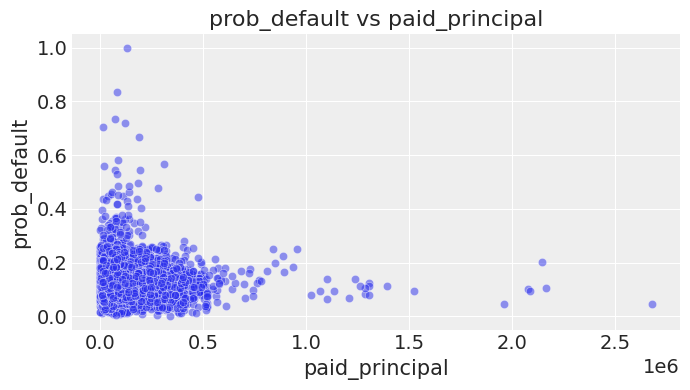

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



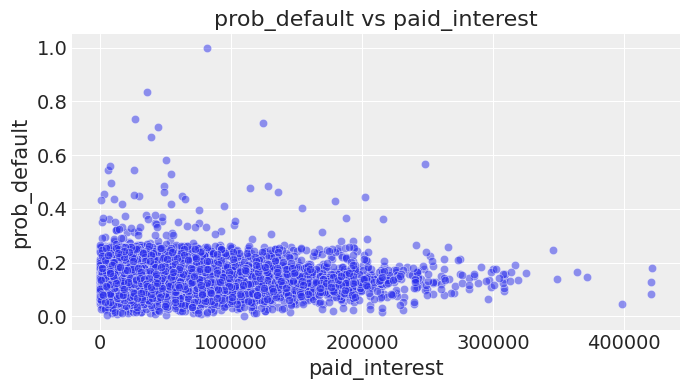

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



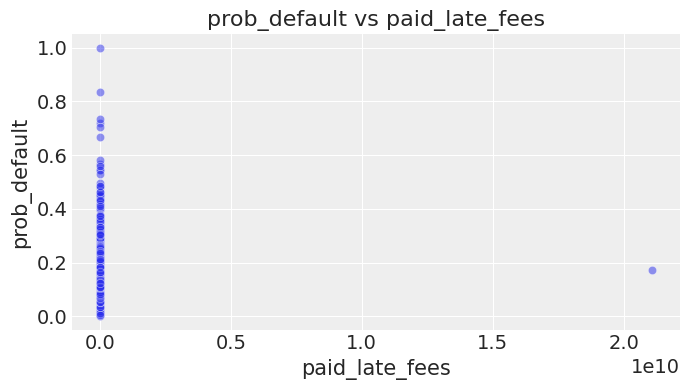

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



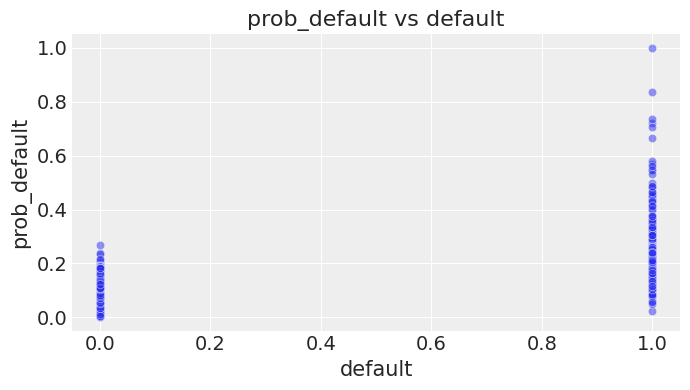

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



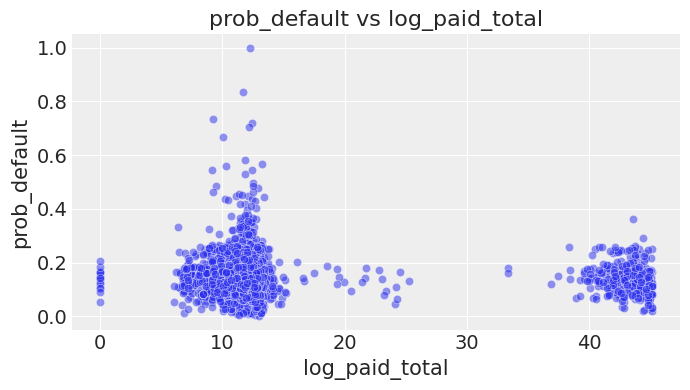

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



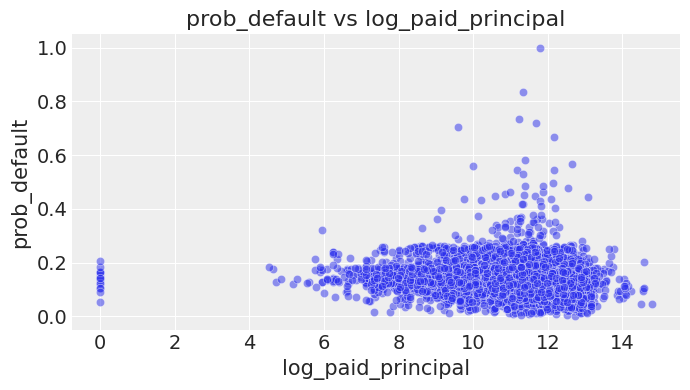

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



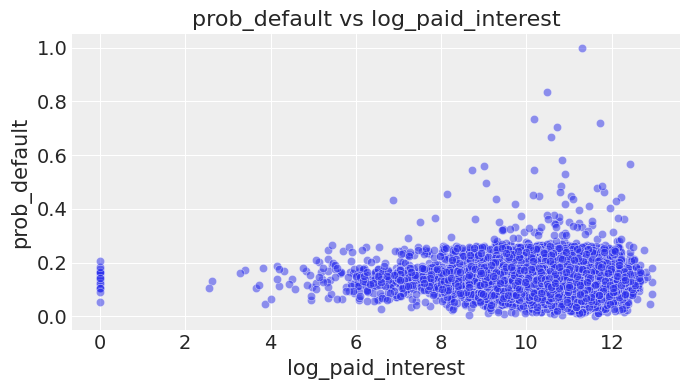

/tmp/ipython-input-1706430244.py:29: UserWarning:

The figure layout has changed to tight



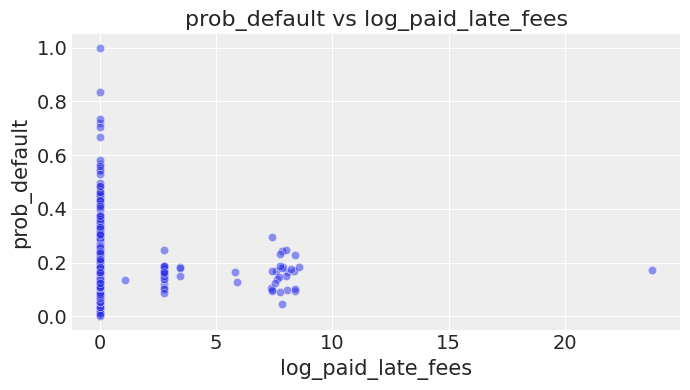

In [ ]:
plot_all_vs_prob_default(df, target='prob_default')

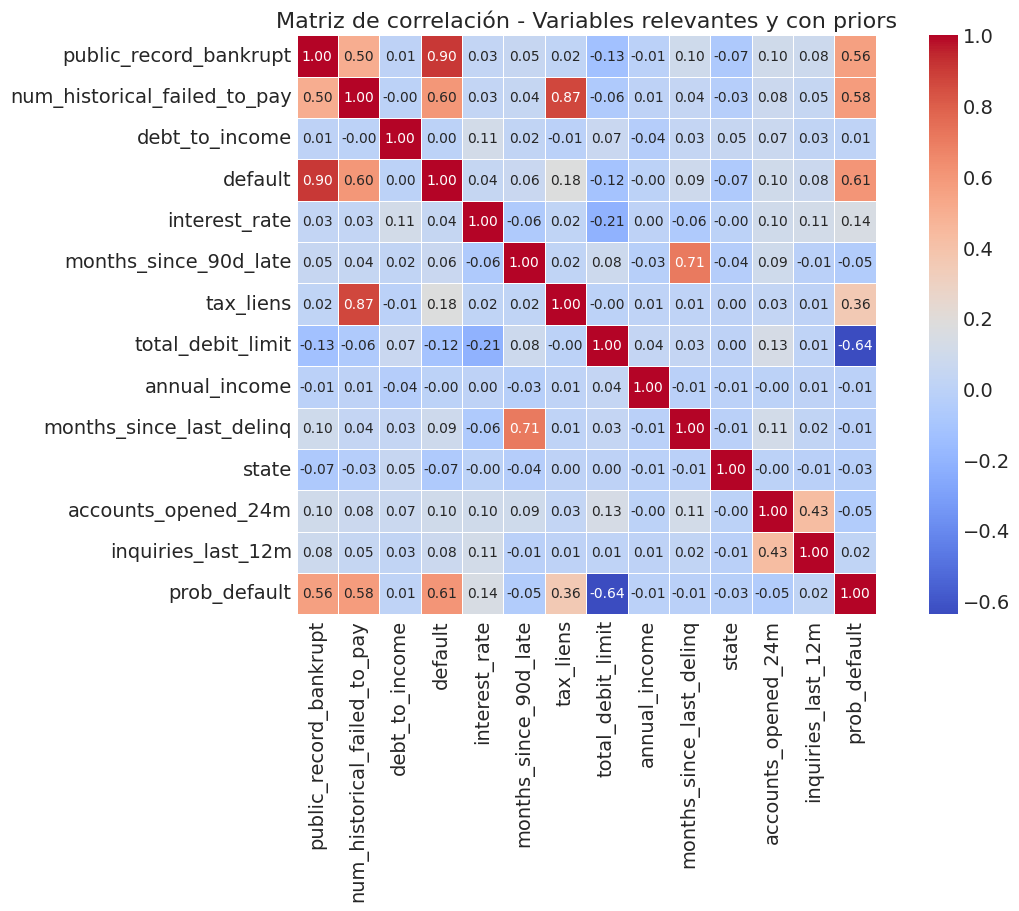

🔹 Correlaciones con la variable objetivo (default):

default                         1.000000
public_record_bankrupt          0.904446
prob_default                    0.608893
num_historical_failed_to_pay    0.598478
tax_liens                       0.179607
accounts_opened_24m             0.098637
months_since_last_delinq        0.085781
inquiries_last_12m              0.077291
months_since_90d_late           0.062588
interest_rate                   0.044641
debt_to_income                  0.001561
annual_income                  -0.003240
state                          -0.066529
total_debit_limit              -0.116958
Name: default, dtype: float64


In [ ]:
# correlacion matriz
target = 'default'  # también podrías usar 'prob_default' si lo prefieres

# ---------------------------------------------------------------
# 3️⃣ Calcular la matriz de correlación (solo variables numéricas)
# ---------------------------------------------------------------
corr = df.corr(numeric_only=True)

# ---------------------------------------------------------------
# 4️⃣ Identificar las variables más correlacionadas con el default
# ---------------------------------------------------------------
corr_target = corr[target].dropna().sort_values(ascending=False)

# Seleccionamos las 10 variables con mayor correlación (en valor absoluto)
top_vars = corr_target.drop(target).abs().sort_values(ascending=False).head(10).index.tolist()

# ---------------------------------------------------------------
# 5️⃣ Incluir las variables con priors definidas en el modelo
# ---------------------------------------------------------------
prior_vars = ['annual_income', 'debt_to_income', 'interest_rate', 'months_since_last_delinq']

# Unir ambas listas, asegurando que no haya duplicados
vars_to_include = list(set(top_vars + prior_vars + [target]))

# Crear la submatriz de correlación con esas variables
corr_subset = df[vars_to_include].corr(numeric_only=True)

# ---------------------------------------------------------------
# 6️⃣ Graficar la matriz de correlación
# ---------------------------------------------------------------
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación - Variables relevantes y con priors", fontsize=16)
plt.show()

# ---------------------------------------------------------------
# 7️⃣ Mostrar correlaciones específicas con la variable objetivo
# ---------------------------------------------------------------
print("🔹 Correlaciones con la variable objetivo (default):\n")
print(corr_target[vars_to_include].sort_values(ascending=False))

# 🧠 Definición de Priors

In [ ]:
vars_modelo = [
    "annual_income",
    "debt_to_income",
    "interest_rate",
    "months_since_last_delinq",
    "num_historical_failed_to_pay",
    "public_record_bankrupt"
]

subset = vars_modelo + ["default"]
data_clean = df.dropna(subset=subset).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean[vars_modelo])
y = data_clean["default"].astype(int).values

print("X.shape:", X_scaled.shape)
print("y.shape:", y.shape)
print("Any NaNs in X?", np.isnan(X_scaled).any())
print("Any NaNs in y?", np.isnan(y).any())
print("unique(y):", np.unique(y))

X.shape: (4331, 6)
y.shape: (4331,)
Any NaNs in X? False
Any NaNs in y? False
unique(y): [0 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño entrenamiento: (3464, 6)
Tamaño test: (867, 6)


#### 🧮(Nu) Estimación de los Betas y Modelo

In [ ]:

with pm.Model() as logistic_model:

    # Priors personalizados (según tu imagen)
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    beta_annual_income = pm.Normal("beta_annual_income", mu=0, sigma=0.5)
    beta_debt_to_income = pm.Normal("beta_debt_to_income", mu=0, sigma=0.5)
    beta_interest_rate = pm.Normal("beta_interest_rate", mu=0, sigma=0.5)
    beta_months_since_last_delinq = pm.Normal("beta_months_since_last_delinq", mu=0, sigma=1)
    beta_num_historical_failed_to_pay = pm.Normal("beta_num_historical_failed_to_pay", mu=1, sigma=1)
    beta_public_record_bankrupt = pm.Normal("beta_public_record_bankrupt", mu=2, sigma=1)

    # Vector de betas
    betas = [
        beta_annual_income,
        beta_debt_to_income,
        beta_interest_rate,
        beta_months_since_last_delinq,
        beta_num_historical_failed_to_pay,
        beta_public_record_bankrupt,
    ]

    # Logit lineal (intercepto + suma ponderada)
    logit_p = intercept + pm.math.dot(X_train, pm.math.stack(betas))

    # Likelihood (variable dependiente)
    y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y_train)

    # Muestreo
    trace = pm.sample(10000, tune=2500, target_accept=0.9, random_seed=42, cores=2)

Output()

ERROR:pymc.stats.convergence:There were 19285 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/tmp/ipython-input-3398436834.py:29: UserWarning:

The figure layout has changed to tight



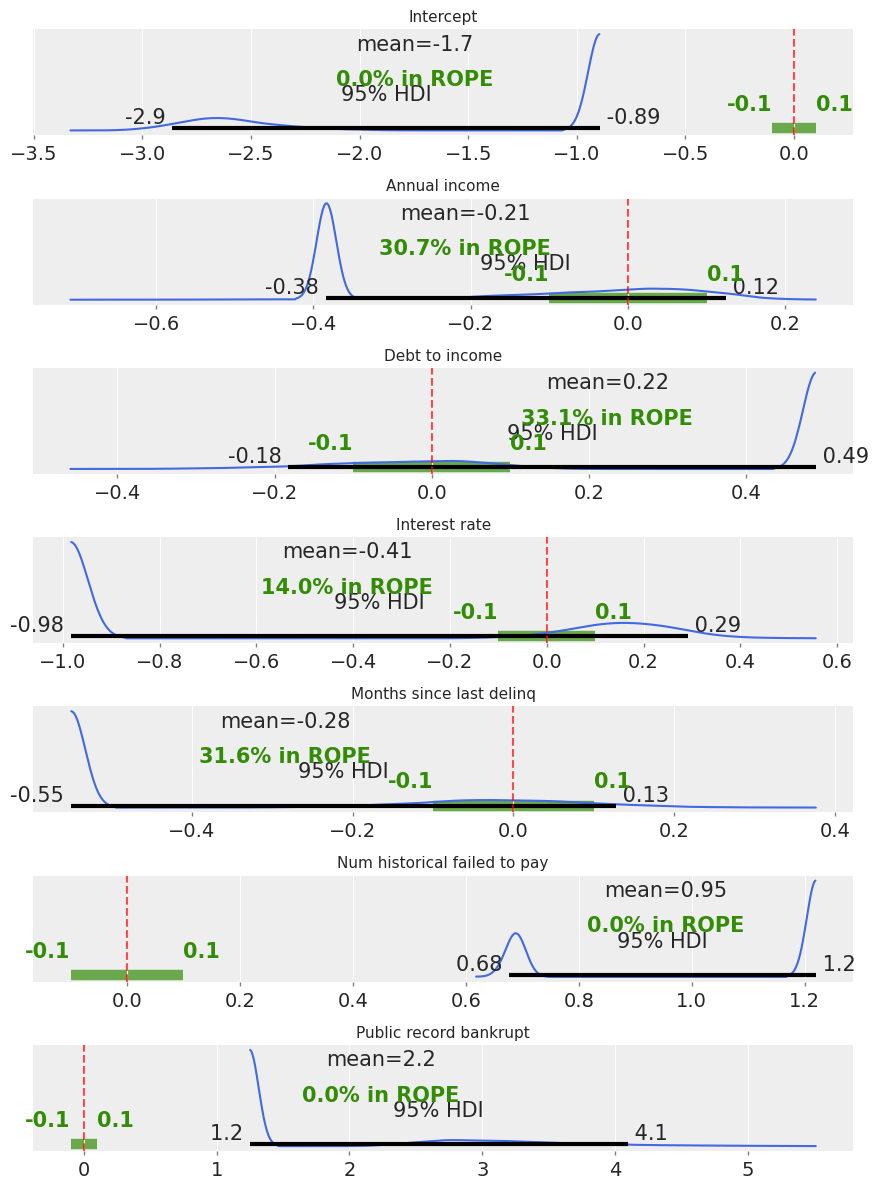

In [ ]:
vars_modelo = [
    "intercept",
    "beta_annual_income",
    "beta_debt_to_income",
    "beta_interest_rate",
    "beta_months_since_last_delinq",
    "beta_num_historical_failed_to_pay",
    "beta_public_record_bankrupt"
]

# Estilo y colores
az.style.use("arviz-darkgrid")

# Gráfico de densidades posterior con línea vertical en 0
fig, axes = plt.subplots(len(vars_modelo), 1, figsize=(9, 12))
for i, var in enumerate(vars_modelo):
    az.plot_posterior(
        trace,
        var_names=[var],
        hdi_prob=0.95,
        ax=axes[i],
        rope=(-0.1, 0.1),  # zona de irrelevancia práctica opcional
        color="royalblue",
        point_estimate="mean",
    )
    axes[i].axvline(0, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(var.replace("beta_", "").replace("_", " ").capitalize(), fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
posterior_df = az.extract(trace).to_dataframe()
param_names = [
    "intercept",
    "beta_annual_income",
    "beta_debt_to_income",
    "beta_interest_rate",
    "beta_months_since_last_delinq",
    "beta_num_historical_failed_to_pay",
    "beta_public_record_bankrupt"
]

# Crear gráfico interactivo de densidades
fig = ff.create_distplot(
    [posterior_df[p] for p in param_names],
    group_labels=param_names,
    show_hist=False,
    show_rug=False
)
fig.update_layout(
    title="Distribuciones Posteriores",
    xaxis_title="Valor del parámetro",
    yaxis_title="Densidad",
    width=1000,
    height=600,
)
fig.show()

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data ap

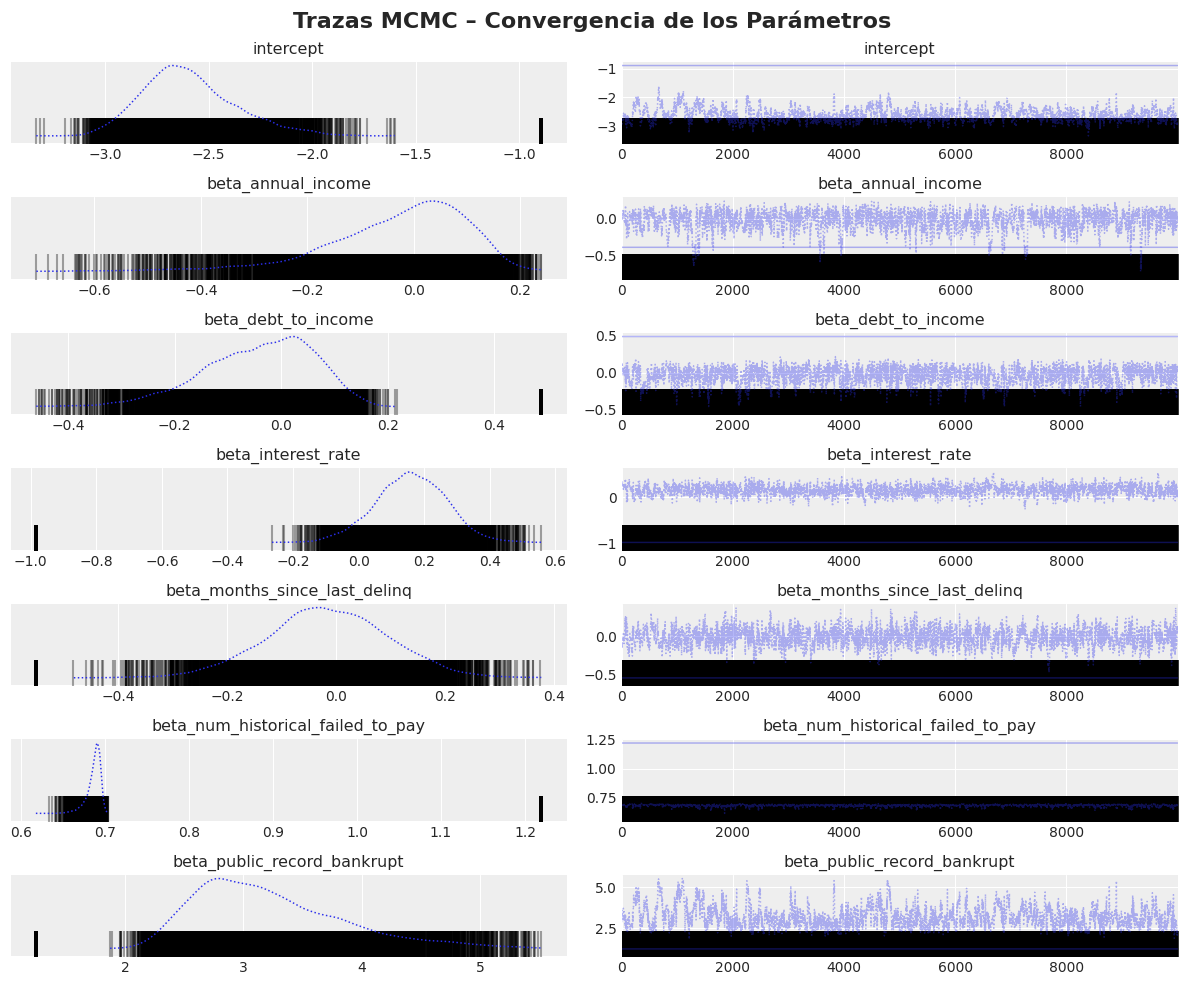

In [ ]:
az.plot_trace(
    trace,
    var_names=[
        "intercept",
        "beta_annual_income",
        "beta_debt_to_income",
        "beta_interest_rate",
        "beta_months_since_last_delinq",
        "beta_num_historical_failed_to_pay",
        "beta_public_record_bankrupt"
    ],
    figsize=(12, 10)
)
plt.suptitle("Trazas MCMC – Convergencia de los Parámetros", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

##### ⚙️ Modelo Definitivo

In [ ]:
from sklearn.preprocessing import StandardScaler

vars_modelo = [
    "interest_rate",
    "num_historical_failed_to_pay",
    "public_record_bankrupt"
]

subset = vars_modelo + ["default"]
data_clean = df.dropna(subset=subset).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean[vars_modelo])
y = data_clean["default"].astype(int).values

print("X.shape:", X_scaled.shape)
print("y.shape:", y.shape)
print("Any NaNs in X?", np.isnan(X_scaled).any())
print("Any NaNs in y?", np.isnan(y).any())
print("unique(y):", np.unique(y))

X.shape: (10000, 3)
y.shape: (10000,)
Any NaNs in X? False
Any NaNs in y? False
unique(y): [0 1]


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño entrenamiento: (8000, 3)
Tamaño test: (2000, 3)


In [ ]:
with pm.Model() as logistic_model:

    # Priors personalizados (según tu imagen)
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    beta_interest_rate = pm.Normal("beta_interest_rate", mu=0, sigma=0.5)
    beta_num_historical_failed_to_pay = pm.Normal("beta_num_historical_failed_to_pay", mu=1, sigma=1)
    beta_public_record_bankrupt = pm.Normal("beta_public_record_bankrupt", mu=2, sigma=1)

    # Vector de betas
    betas = [
        beta_interest_rate,
        beta_num_historical_failed_to_pay,
        beta_public_record_bankrupt,
    ]

    # Logit lineal (intercepto + suma ponderada)
    logit_p = intercept + pm.math.dot(X_train, pm.math.stack(betas))

    # Likelihood (variable dependiente)
    y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y_train)

    # Muestreo
    trace = pm.sample(10000, tune=2500, target_accept=0.9, random_seed=42, cores=2)

Output()

ERROR:pymc.stats.convergence:There were 19164 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/tmp/ipython-input-742672322.py:26: UserWarning:

The figure layout has changed to tight



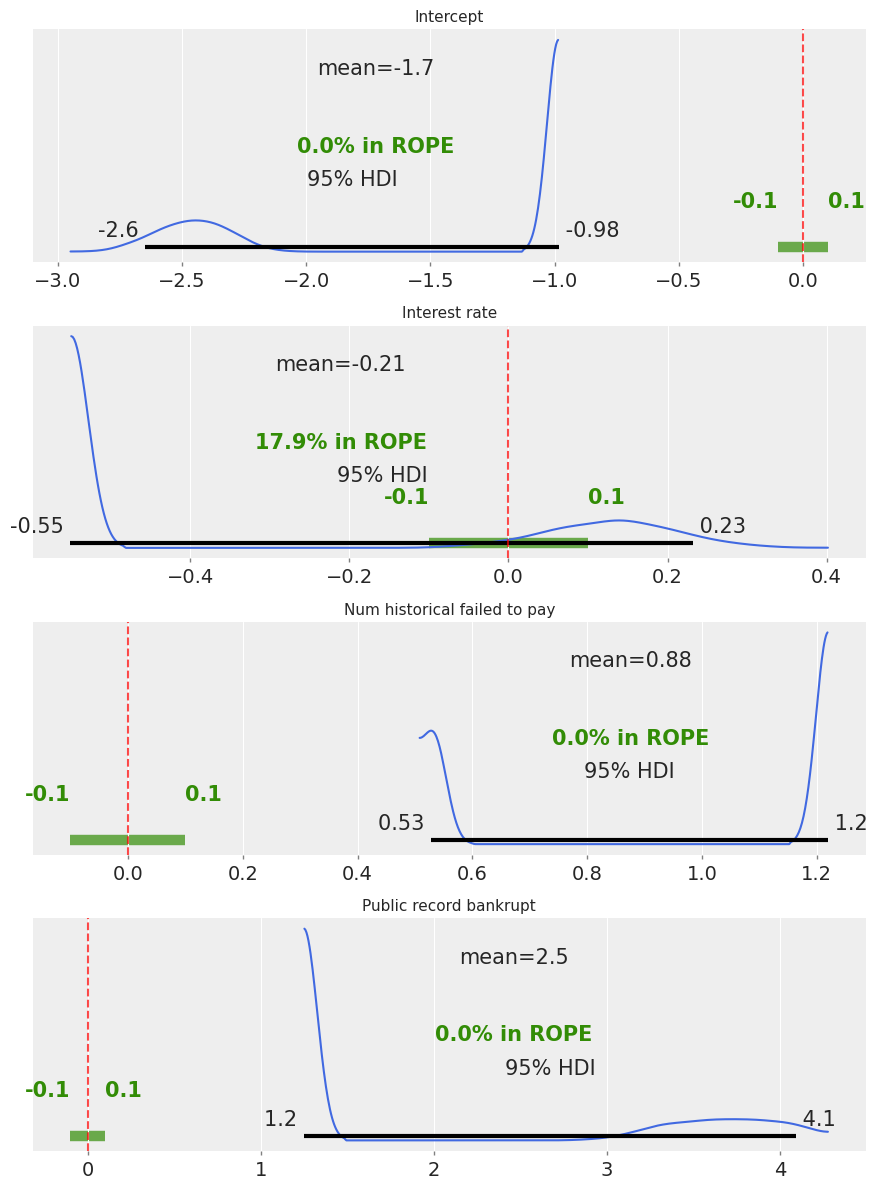

In [ ]:
vars_modelo = [
    "intercept",
    "beta_interest_rate",
    "beta_num_historical_failed_to_pay",
    "beta_public_record_bankrupt"
]

# Estilo y colores
az.style.use("arviz-darkgrid")

# Gráfico de densidades posterior con línea vertical en 0
fig, axes = plt.subplots(len(vars_modelo), 1, figsize=(9, 12))
for i, var in enumerate(vars_modelo):
    az.plot_posterior(
        trace,
        var_names=[var],
        hdi_prob=0.95,
        ax=axes[i],
        rope=(-0.1, 0.1),
        color="royalblue",
        point_estimate="mean",
    )
    axes[i].axvline(0, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(var.replace("beta_", "").replace("_", " ").capitalize(), fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import arviz as az
import plotly.figure_factory as ff
import plotly.graph_objects as go
from ipywidgets import widgets, interact

# --- Extraer posterior ---
posterior_df = az.extract(trace).to_dataframe()

# --- Parámetros a visualizar ---
param_names = [
    "intercept",
    "beta_interest_rate",
    "beta_num_historical_failed_to_pay",
    "beta_public_record_bankrupt"
]

# --- Widget interactivo para elegir parámetros ---
param_selector = widgets.SelectMultiple(
    options=param_names,
    value=["intercept", "beta_interest_rate"],
    description='📊 Parámetros:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%', height='160px')
)

def plot_posteriors(params):
    fig = ff.create_distplot(
        [posterior_df[p] for p in params],
        group_labels=params,
        show_hist=False,
        show_rug=False
    )
    fig.update_layout(
        title=f"📈 Distribuciones Posteriores ({len(params)} parámetros)",
        xaxis_title="Valor del parámetro",
        yaxis_title="Densidad",
        template="plotly_dark",
        width=950,
        height=550,
        legend=dict(title="Parámetros", orientation="h", y=-0.25)
    )
    fig.update_traces(line=dict(width=3))
    fig.show()

interact(plot_posteriors, params=param_selector)


interactive(children=(SelectMultiple(description='📊 Parámetros:', index=(0, 1), layout=Layout(height='160px', …

<function __main__.plot_posteriors(params)>

##### 🔮 Predicción del Modelo con NU (Definitivo)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report


# Asegurar que X_test tenga formato correcto

columnas = ["interest_rate", "num_historical_failed_to_pay", "public_record_bankrupt"]

if isinstance(X_test, np.ndarray):
    # Si es un array de NumPy, lo convertimos a DataFrame con nombres
    X_test = pd.DataFrame(X_test, columns=columnas)
else:
    # Si ya es DataFrame, nos aseguramos de conservar solo las columnas necesarias y en orden
    X_test = X_test[columnas].copy()

#  Extraer posterior y apilar muestras (chain)

posterior = trace.posterior
posterior_stacked = posterior.stack(sample=("chain", "draw"))

# Extraer arrays de cada parámetro
intercepts = posterior_stacked["intercept"].values
b_ir = posterior_stacked["beta_interest_rate"].values
b_failed = posterior_stacked["beta_num_historical_failed_to_pay"].values
b_bankrupt = posterior_stacked["beta_public_record_bankrupt"].values

# Apilar betas
betas_samples = np.column_stack([b_ir, b_failed, b_bankrupt])


#  Calcular la probabilidad de default para cada muestra y observación

n_samples = betas_samples.shape[0]
n_test = X_test.shape[0]

logit_samples = intercepts[:, None] + betas_samples @ X_test.T
p_samples = 1 / (1 + np.exp(-logit_samples))


# Resumen predictivo por observación (media + intervalo 95%)

p_mean = p_samples.mean(axis=0)
p_hdi_lower = np.percentile(p_samples, 2.5, axis=0)
p_hdi_upper = np.percentile(p_samples, 97.5, axis=0)


#  Clasificación binaria (prob > 0.5)

y_pred_mean = (p_mean > 0.5).astype(int)


# Métricas de evaluación

print("Accuracy (posterior-mean):", accuracy_score(y_test, y_pred_mean))
print("AUC (posterior probs):", roc_auc_score(y_test, p_mean))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_mean))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_mean, digits=3))


# DataFrame con resultados por observación

df_res = pd.DataFrame({
    "y_true": y_test,
    "p_mean": p_mean,
    "p_hdi_2.5": p_hdi_lower,
    "p_hdi_97.5": p_hdi_upper,
    "y_pred_mean": y_pred_mean
})

print("\nPrimeras observaciones:")
print(df_res.head(10))

Accuracy (posterior-mean): 0.978
AUC (posterior probs): 0.9977178199103333

Matriz de confusión:
[[1694    0]
 [  44  262]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.975     1.000     0.987      1694
           1      1.000     0.856     0.923       306

    accuracy                          0.978      2000
   macro avg      0.987     0.928     0.955      2000
weighted avg      0.979     0.978     0.977      2000


Primeras observaciones:
   y_true    p_mean  p_hdi_2.5  p_hdi_97.5  y_pred_mean
0       0  0.127915   0.013620    0.238961            0
1       0  0.065991   0.017559    0.111213            0
2       1  0.983501   0.967627    0.999907            1
3       0  0.111617   0.014728    0.205637            0
4       0  0.073431   0.017246    0.126803            0
5       0  0.093019   0.016063    0.167420            0
6       0  0.078925   0.016963    0.138247            0
7       0  0.056938   0.017851    0.092046       

In [ ]:
# =====================================================
# TABLA 1: RESUMEN DEL POSTERIOR DE LOS PARÁMETROS
# =====================================================

import arviz as az

summary = az.summary(
    trace,
    hdi_prob=0.95
)[["mean", "sd", "hdi_2.5%", "hdi_97.5%"]]

print("\n\n=== TABLA 1: RESUMEN POSTERIOR DE PARÁMETROS ===")
print(summary)


# =====================================================
# TABLA 2: MÉTRICAS DE DESEMPEÑO (AUC, PRECISION, RECALL, F1)
# =====================================================

from sklearn.metrics import precision_score, recall_score, f1_score

metrics_table = pd.DataFrame({
    "AUC": [roc_auc_score(y_test, p_mean)],
    "Precision": [precision_score(y_test, y_pred_mean)],
    "Recall": [recall_score(y_test, y_pred_mean)],
    "F1-score": [f1_score(y_test, y_pred_mean)]
})

print("\n\n=== TABLA 2: MÉTRICAS GLOBALES ===")
print(metrics_table)


# =====================================================
# TABLA 3: MATRIZ DE CONFUSIÓN (FORMATO TABULAR)
# =====================================================

cm = confusion_matrix(y_test, y_pred_mean)

cm_table = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Predicho 0", "Predicho 1"]
)

print("\n\n=== TABLA 3: MATRIZ DE CONFUSIÓN ===")
print(cm_table)


# =====================================================
# TABLA 4: PROBABILIDADES POSTERIORES POR OBSERVACIÓN
# =====================================================

print("\n\n=== TABLA 4: PROBABILIDADES POSTERIORES (Primeras 15 observaciones) ===")
print(df_res.head(15))




=== TABLA 1: RESUMEN POSTERIOR DE PARÁMETROS ===
                                    mean     sd  hdi_2.5%  hdi_97.5%
beta_interest_rate                -0.211  0.345    -0.551      0.232
beta_num_historical_failed_to_pay  0.876  0.343     0.528      1.219
beta_public_record_bankrupt        2.462  1.234     1.248      4.092
intercept                         -1.721  0.744    -2.647     -0.984


=== TABLA 2: MÉTRICAS GLOBALES ===
        AUC  Precision    Recall  F1-score
0  0.997718        1.0  0.856209  0.922535


=== TABLA 3: MATRIZ DE CONFUSIÓN ===
        Predicho 0  Predicho 1
Real 0        1694           0
Real 1          44         262


=== TABLA 4: PROBABILIDADES POSTERIORES (Primeras 15 observaciones) ===
    y_true    p_mean  p_hdi_2.5  p_hdi_97.5  y_pred_mean
0        0  0.127915   0.013620    0.238961            0
1        0  0.065991   0.017559    0.111213            0
2        1  0.983501   0.967627    0.999907            1
3        0  0.111617   0.014728    0.205637    

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning:

Your data appears to have a single value or no finite values

/tmp/ipython-input-4066859549.py:12: UserWarning:

The figure layout has changed to tight



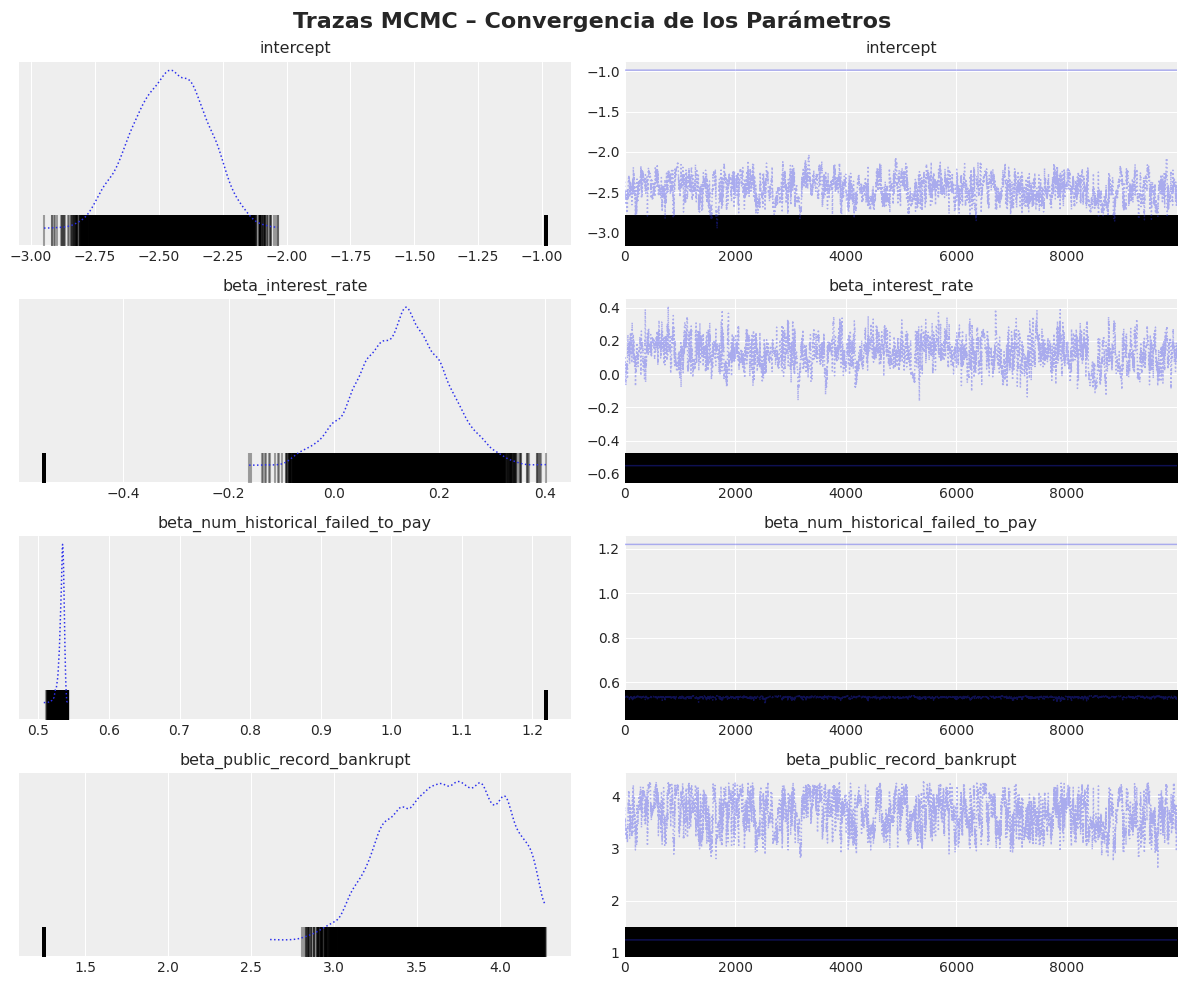

In [ ]:
az.plot_trace(
    trace,
    var_names=[
        "intercept",
        "beta_interest_rate",
        "beta_num_historical_failed_to_pay",
        "beta_public_record_bankrupt"
    ],
    figsize=(12, 10)
)
plt.suptitle("Trazas MCMC – Convergencia de los Parámetros", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

#### 🎲Metropolis hasting o Gibbs

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño entrenamiento: (8000, 3)
Tamaño test: (2000, 3)


Output()

/usr/local/lib/python3.12/dist-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning:

overflow encountered in exp

                                    mean     sd  hdi_3%  hdi_97%  mcse_mean  \
beta_interest_rate                 0.103  0.271  -0.397    0.612      0.006   
beta_num_historical_failed_to_pay  7.224  0.431   6.445    8.048      0.012   
beta_public_record_bankrupt        2.698  0.813   1.157    4.110      0.029   
intercept                         -4.384  0.457  -5.236   -3.510      0.018   

                                   mcse_sd  ess_bulk  ess_tail  r_hat  
beta_interest_rate                   0.005    1942.0    2196.0    1.0  
beta_num_historical_failed_to_pay    0.008    1239.0    1941.0    1.0  
beta_public_record_bankrupt          0.018     802.0    1152.0    1.0  
intercept                            0.010     676.0     998.0    1.0  


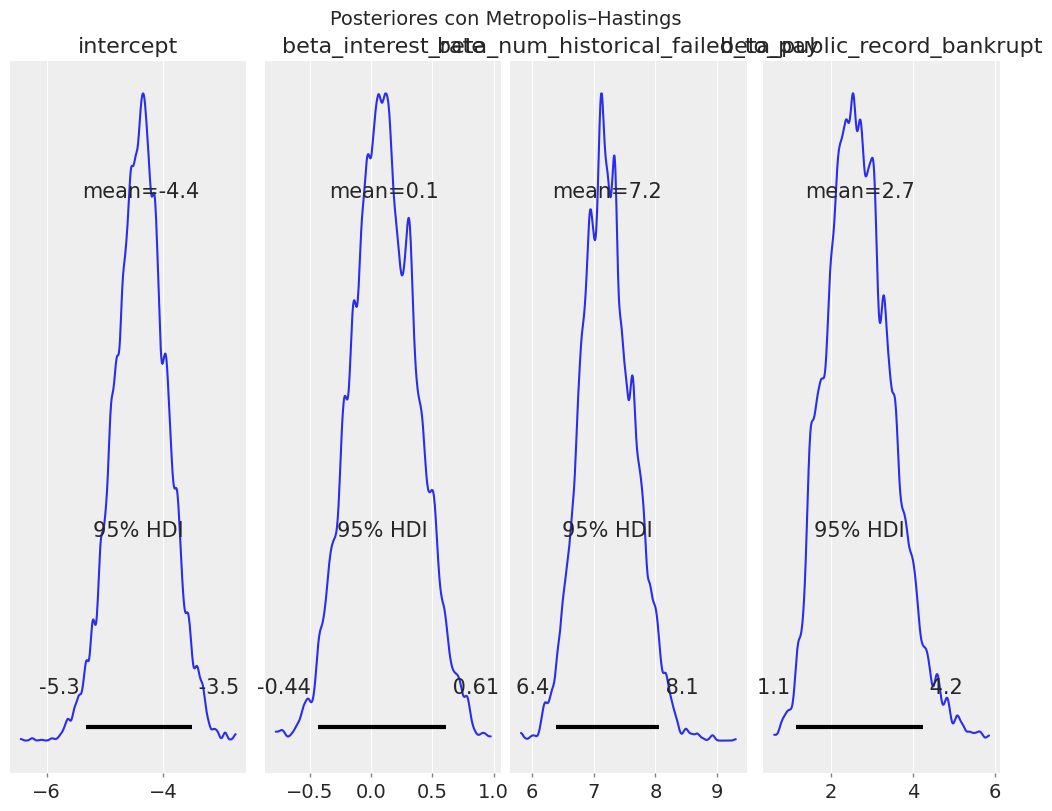

In [ ]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

with pm.Model() as logistic_model:

    # Priors personalizados
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    beta_interest_rate = pm.Normal("beta_interest_rate", mu=0, sigma=0.5)
    beta_num_historical_failed_to_pay = pm.Normal("beta_num_historical_failed_to_pay", mu=1, sigma=1)
    beta_public_record_bankrupt = pm.Normal("beta_public_record_bankrupt", mu=2, sigma=1)

    # Vector de betas
    betas = [
        beta_interest_rate,
        beta_num_historical_failed_to_pay,
        beta_public_record_bankrupt
    ]

    #  Logit lineal
    logit_p = intercept + pm.math.dot(X_train, pm.math.stack(betas))

    #  Likelihood
    y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y_train)

    #  MCMC con Metropolis–Hastings
    step = pm.Metropolis()  # Aquí cambiamos el muestreador
    trace = pm.sample(
        draws=5000,
        tune=2000,
        step=step,
        random_seed=42,
        progressbar=True
    )

# Resumen de resultados
summary = az.summary(trace)
print(summary)

# Gráfico de distribuciones posteriores
az.plot_posterior(
    trace,
    var_names=[
        "intercept",
        "beta_interest_rate",
        "beta_num_historical_failed_to_pay",
        "beta_public_record_bankrupt"
    ],
    hdi_prob=0.95,
    figsize=(10, 8)
)
plt.suptitle("Posteriores con Metropolis–Hastings", fontsize=14)
plt.show()


In [ ]:
import arviz as az
import plotly.graph_objects as go
import pandas as pd

# Extraer los valores del trace como DataFrame
posterior_df = az.extract(trace).to_dataframe()

# Variables que quieres graficar
variables = [
    "intercept",
    "beta_interest_rate",
    "beta_num_historical_failed_to_pay",
    "beta_public_record_bankrupt"
]

# Crear figura interactiva
fig = go.Figure()

for var in variables:
    fig.add_trace(go.Histogram(
        x=posterior_df[var],
        name=var,
        nbinsx=40,
        opacity=0.6,
        histnorm="probability density"
    ))

fig.update_layout(
    title="Distribuciones Posteriores Interactivas (Metropolis–Hastings)",
    xaxis_title="Valor del parámetro",
    yaxis_title="Densidad",
    barmode="overlay",
    hovermode="x unified",
    template="plotly_white",
    width=950,
    height=600
)

fig.show()


#### 📈Predicción del Modelo Metropolis hasting

In [ ]:
intercept_mean = trace.posterior["intercept"].mean(dim=("chain","draw")).item()

beta_means = np.array([
    trace.posterior["beta_interest_rate"].mean(dim=("chain","draw")).item(),
    trace.posterior["beta_num_historical_failed_to_pay"].mean(dim=("chain","draw")).item(),
    trace.posterior["beta_public_record_bankrupt"].mean(dim=("chain","draw")).item()
])

# Verifica shapes
print("X_test.shape:", X_test.shape)
print("beta_means.shape:", beta_means.shape)

# Calcular logit y probabilidades predichas
logit_p_test = intercept_mean + np.dot(X_test, beta_means)
p_test = 1 / (1 + np.exp(-logit_p_test))

# Clasificación binaria con umbral 0.5
y_pred = (p_test > 0.5).astype(int)

X_test.shape: (2000, 3)
beta_means.shape: (3,)


In [ ]:
posterior = trace.posterior
# apilar chain+draw en un eje "sample"
posterior_stacked = posterior.stack(sample=("chain","draw"))

# Extraer arrays (samples,)
intercepts = posterior_stacked["intercept"].values
b_ir = posterior_stacked["beta_interest_rate"].values
b_failed = posterior_stacked["beta_num_historical_failed_to_pay"].values
b_bankrupt = posterior_stacked["beta_public_record_bankrupt"].values

# apilar betas
betas_samples = np.column_stack([
    b_ir, b_failed, b_bankrupt
])

n_samples = betas_samples.shape[0]
n_test = X_test.shape[0]

# 2) Calcular la probabilidad para cada muestra y cada observación:

logit_samples = intercepts[:, None] + betas_samples @ X_test.T
p_samples = 1 / (1 + np.exp(-logit_samples))

# 3) Resumen predictivo por observación:
p_mean = p_samples.mean(axis=0)
p_hdi_lower = np.percentile(p_samples, 2.5, axis=0)
p_hdi_upper = np.percentile(p_samples, 97.5, axis=0)

# 4) Clasificación puntual (por ejemplo, por la media posterior)
y_pred_mean = (p_mean > 0.5).astype(int)

# 5) Métricas
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
print("Accuracy (posterior-mean):", accuracy_score(y_test, y_pred_mean))
print("AUC (posterior probs):", roc_auc_score(y_test, p_mean))

# 6) Mostrar resultados para primeras observaciones de test
import pandas as pd
df_res = pd.DataFrame({
    "y_true": y_test,
    "p_mean": p_mean,
    "p_hdi_2.5": p_hdi_lower,
    "p_hdi_97.5": p_hdi_upper,
    "y_pred_mean": y_pred_mean
})
print(df_res.head(10))

Accuracy (posterior-mean): 1.0
AUC (posterior probs): 1.0
   y_true    p_mean  p_hdi_2.5  p_hdi_97.5  y_pred_mean
0       0  0.000813   0.000231    0.001796            0
1       0  0.000933   0.000346    0.001845            0
2       1  0.999914   0.999303    1.000000            1
3       0  0.000824   0.000269    0.001698            0
4       0  0.000901   0.000349    0.001725            0
5       0  0.000849   0.000309    0.001645            0
6       0  0.000882   0.000342    0.001679            0
7       0  0.000989   0.000327    0.002087            0
8       0  0.000811   0.000219    0.001856            0
9       0  0.000989   0.000327    0.002087            0
